# *Trabajo Practico N°1 - Laboratorio de Datos*

**Fecha:** 23/02/2026

## Importación de librerías y datasets

Importamos los módulos que nos pueden servir para el trabajo práctico

In [ ]:
!pip install formulaic

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn.objects as so
from formulaic import Formula,model_matrix

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold

Abrimos los archivos que vamos a usar

In [ ]:
full_data  = pd.read_csv("full_data.csv")
clima  = pd.read_csv("clima_actualizado.csv")
viajes_diarios  = pd.read_csv("viajes_diarios.csv")

Vimos que el archivo de clima subido al campus tenía información faltante. Por lo que usaremos "clima_actualizado". Que descargamos desde el mismo origen pero con fechas coincidentes a "full_data". Mas adelante aclaramos este punto.

# *Procesamiento de datos*

## Ejercicio 1

Vemos que información tiene nuestro archivo principal, full_data:

In [ ]:
full_data.shape

(12528, 17)

Tiene 12.528 fiilas y 17 variables

In [ ]:
full_data.head(1)

,station_id,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,is_charging_station,status,is_installed,is_renting,is_returning,traffic,num_bikes_available_types.mechanical,num_bikes_available_types.ebike,Date,hora,dia
0,420,3,1,8,0,1.745880e+09,False,IN_SERVICE,1,1,1,NaN,3,0,2025-04-28,23:28:05,Monday


Nos quedamos con las variables que nos interesan del DataFrame original y creamos uno nuevo con las mismas

In [ ]:
datos_limpios = full_data[[
    "station_id",
    "num_bikes_available",
    "num_bikes_disabled",
    "num_docks_available",
    "num_docks_disabled",
    "Date",
    "hora",
    "dia"
    ]].copy()

Usamos .copy() para no modificar el DataFrame original

In [ ]:
datos_limpios.head(1)

,station_id,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,Date,hora,dia
0,420,3,1,8,0,2025-04-28,23:28:05,Monday


## Ejercicio 2

Reeplazamos el listado con los nombres de columnas por los mismos en español

In [ ]:
rename_dict = {"station_id" : "estacion",
               "num_bikes_available": "bicis_disponibles",
               "num_bikes_disabled": "bicis_rotas",
               "num_docks_available": "puertos_disponibles",
               "num_docks_disabled" : "puertos_rotos",
               "Date" : "fecha",
               "hora" : "horario",
               "dia" : "dia_semana"}
datos_limpios.rename(columns = rename_dict, inplace = True)

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana
0,420,3,1,8,0,2025-04-28,23:28:05,Monday


## Ejercicio 3

Exploramos los datos que puede tomar la variable "dia_semana"

In [ ]:
datos_limpios.dia_semana.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object)

Creamos un diccionario de traduccion de dias ingles a español y lo aplicamos al DataFrame mediante la funcion map

In [ ]:
diccionario_dias = {
    "Monday" : "Lunes",
    "Tuesday" : "Martes",
    "Wednesday" : "Miercoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sabado",
    "Sunday": "Domingo",
}

datos_limpios['dia_semana'] = datos_limpios['dia_semana'].map(diccionario_dias)

In [ ]:
datos_limpios.dia_semana.unique()

array(['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado',
       'Domingo'], dtype=object)

## Ejercicio 4

Llegado a este punto, distinguimos entre los distintos tipos de variables presentes en los datos:

**Categóricas Nominales**
- dia_semana

**Numéricas Discretas**
- bicis_disponibles
- bicis_rotas
- puertos_disponibles
- puertos_rotos
- fecha
- estacion

**Numéricas Continuas**
- horario




## Ejercicio 5

Comprobamos que no haya datos faltantes en la base de datos

In [ ]:
datos_limpios.isna().sum(axis=0)

,0
estacion,0
bicis_disponibles,0
bicis_rotas,0
puertos_disponibles,0
puertos_rotos,0
fecha,0
horario,0
dia_semana,0


## Ejercicio 6

Generamos las columnas "anio", "mes", "dia" y "hora" de forma vectorizada a partir de las columnas "fecha" y "horario"

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes


In [ ]:
datos_limpios["anio"] = datos_limpios["fecha"].str[:4].astype(int)
datos_limpios["mes"]  = datos_limpios["fecha"].str[5:7].astype(int)
datos_limpios["dia"]  = datos_limpios["fecha"].str[8:10].astype(int)
datos_limpios["hora"] = datos_limpios["horario"].str[:2].astype(int)

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23


## Ejercicio 7

Convertimos las columnas "fecha" y "horario" a DateTime

In [ ]:
display(datos_limpios.head(1))
display(type(datos_limpios["horario"][0]))
display(type(datos_limpios["fecha"][0]))

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23


str

str

In [ ]:
datos_limpios ["fecha"] = pd.to_datetime(datos_limpios["fecha"])
datos_limpios["horario"] = pd.to_datetime(
    datos_limpios["horario"],
    format="%H:%M:%S"
).dt.time

In [ ]:
display(datos_limpios.head(1))
display(type(datos_limpios["horario"][0]))
display(type(datos_limpios["fecha"][0]))

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23


datetime.time

pandas._libs.tslibs.timestamps.Timestamp

Observamos que las columnas fecha y horario no cambiaron, solo se modificó su tipo de dato para poder usarlos con más facilidad y tener nuevas funciones.

## Ejercicio 8

Creamos una función que devuelve la estacion según el mes (y el día si es un mes que cambia de estación), y creamos una variable en el df con la información que devuelve esta función

In [ ]:
'''def determinar_estacion_anio (df):
    estacion_anio = []
    for mes, dia in zip(df["mes"].values, df["dia"].values):
        if mes==4 or mes==5 or (mes==3 and dia>=21) or (mes==6 and dia<21):
            estacion_anio.append("Otoño")
        elif mes==7 or mes==8 or (mes==6 and dia>=21) or (mes==9 and dia<21):
            estacion_anio.append("Invierno")
        elif mes==10 or (mes==11) or (mes==9 and dia>=21) or (mes==12 and dia<21):
            estacion_anio.append("Primavera")
        else:
            estacion_anio.append("Verano")
    df["estacion_anio"] = estacion_anio
    return df

datos_limpios = determinar_estacion_anio(datos_limpios)'''

'def determinar_estacion_anio (df):\n    estacion_anio = []\n    for mes, dia in zip(df["mes"].values, df["dia"].values):\n        if mes==4 or mes==5 or (mes==3 and dia>=21) or (mes==6 and dia<21):\n            estacion_anio.append("Otoño")\n        elif mes==7 or mes==8 or (mes==6 and dia>=21) or (mes==9 and dia<21):\n            estacion_anio.append("Invierno")\n        elif mes==10 or (mes==11) or (mes==9 and dia>=21) or (mes==12 and dia<21):\n            estacion_anio.append("Primavera")\n        else:\n            estacion_anio.append("Verano")\n    df["estacion_anio"] = estacion_anio\n    return df\n\ndatos_limpios = determinar_estacion_anio(datos_limpios)'

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23


Usamos .zip() para poder recorrer juntos el mes y dia de las filas del df

### Opción para valientes

Tomamos el mes y el año directamente desde la variable fecha, que es del tipo datetime.

In [ ]:
def determinar_estacion_anio(df):
    mes = df["fecha"].dt.month
    dia = df["fecha"].dt.day

    condiciones = [
        (mes == 4) | (mes == 5) | ((mes == 3) & (dia >= 21)) | ((mes == 6) & (dia < 21)),
        (mes == 7) | (mes == 8) | ((mes == 6) & (dia >= 21)) | ((mes == 9) & (dia < 21)),
        (mes == 10) | (mes == 11) | ((mes == 9) & (dia >= 21)) | ((mes == 12) & (dia < 21)),
    ]
    opciones = ["Otoño", "Invierno", "Primavera"]

    df["estacion_anio"] = np.select(condiciones, opciones, default="Verano")
    return df

np.select es una función de NumPy que evalúa una lista de condiciones de forma vectorizada y asigna el valor correspondiente según cuál condición sea True. Cobra mayor utilidad en datasets grandes, siendo más eficiente que iterar fila por fila con bucles o .apply()

In [ ]:
datos_limpios = determinar_estacion_anio(datos_limpios)

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora,estacion_anio
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23,Otoño


## Archivo full_data.csv

Analizamos la cantidad de registros por mes:

In [ ]:
datos_limpios.groupby('mes').agg(registro=('mes', 'count')).sort_values(by="registro",ascending=True)

,registro
mes,
4,92
2,222
6,1308
7,1322
1,1336
11,1346
9,1354
12,1356
8,1378


Podemos ver que en febrero y abril hay muy pocos datos, y en marzo directamente no hay. Esto es porque el archivo recopila datos desde finales de abril de 2025 hasta principios de febrero de 2026

## Archivo clima.csv

En el archivo full_data tenemos datos desde el 2025-04-28 hasta el 2026-02-06, y en el archivo de clima (que lo vamos a usar mas adelante en el trabajo práctico), datos desde el 2025-03-01 hasta el 2025-12-31, asi que desde la pagina de donde fue extraido el archivo de clima, vamos a extraer el mismo pero adaptado a las fechas que precisamos.

Seguiremos trabajando con la variable clima pero el Data Frame tendrá los datos del archivo "clima_actualizado" con las fechas que coinciden con full_data. Por lo tanto ahora no deberíamos tener datos faltantes.

In [ ]:
clima.shape

(285, 11)

El archivo tiene 285 filas y 11 variables

In [ ]:
clima.head(1)

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2025-04-28 00:00:00,16.9,12.3,22.5,0.0,NaN,NaN,5.6,NaN,1017.5,NaN


Nos quedamos solo con las columnas que nos interesan (las que tenia el archivo dado, sacando 2 que no nos iban a ser útiles), renombramos las columnas y cambiamos el tipo de dato fecha, al igual que en el archivo full_data

In [ ]:
clima = clima[["date","tavg","tmin","tmax","prcp","wspd","pres"]]

rename_dict_clima = {
                "date" : "fecha",
                "tavg" : "temp_promedio",
                "tmin": "temp_min",
                "tmax": "temp_max",
                "prcp": "precipitacion_total",
                "wspd" : "velocidad_viento",
                "pres" : "presion_aire"}
clima.rename(columns = rename_dict_clima, inplace = True)

clima['fecha'] = pd.to_datetime(clima["fecha"])

In [ ]:
clima.head(1)

,fecha,temp_promedio,temp_min,temp_max,precipitacion_total,velocidad_viento,presion_aire
0,2025-04-28,16.9,12.3,22.5,0.0,5.6,1017.5


Revisamos si tiene datos faltantes

In [ ]:
clima.isna().sum()

,0
fecha,0
temp_promedio,0
temp_min,0
temp_max,0
precipitacion_total,0
velocidad_viento,0
presion_aire,0


# *Análisis descriptivos*

## Ejercicio 9

Creamos el DataFrame "datos_agrupados" que va a contener la información que tenia "datos_limpios" pero sumando la cantidad total de bicis disponibles y rotas, y puertos disponibles:

In [ ]:
con = sqlite3.connect(":memory:")
datos_limpios.to_sql("datos_limpios", con , index=False, if_exists="replace")
datos_agrupados = pd.read_sql_query(
    """SELECT fecha, hora, dia_semana, dia, mes, anio, estacion_anio,
        SUM(bicis_disponibles) AS cantidad_bicis_disponibles,
        SUM(bicis_rotas) AS cantidad_bicis_rotas,
        SUM(puertos_disponibles) AS cantidad_puertos_disponibles
        FROM datos_limpios
        GROUP BY fecha,hora
    """, con)


In [ ]:
datos_agrupados.head(1)

,fecha,hora,dia_semana,dia,mes,anio,estacion_anio,cantidad_bicis_disponibles,cantidad_bicis_rotas,cantidad_puertos_disponibles
0,2025-04-28 00:00:00,23,Lunes,28,4,2025,Otoño,14,3,15


## Ejercicio 10

¿En qué estación del año suele haber más bicis disponibles y puertos disponibles?

Formateamos la columna `fecha` a datetime para una mejor visualización en los gráficos.

In [ ]:
datos_agrupados["fecha"] = pd.to_datetime(datos_agrupados["fecha"])

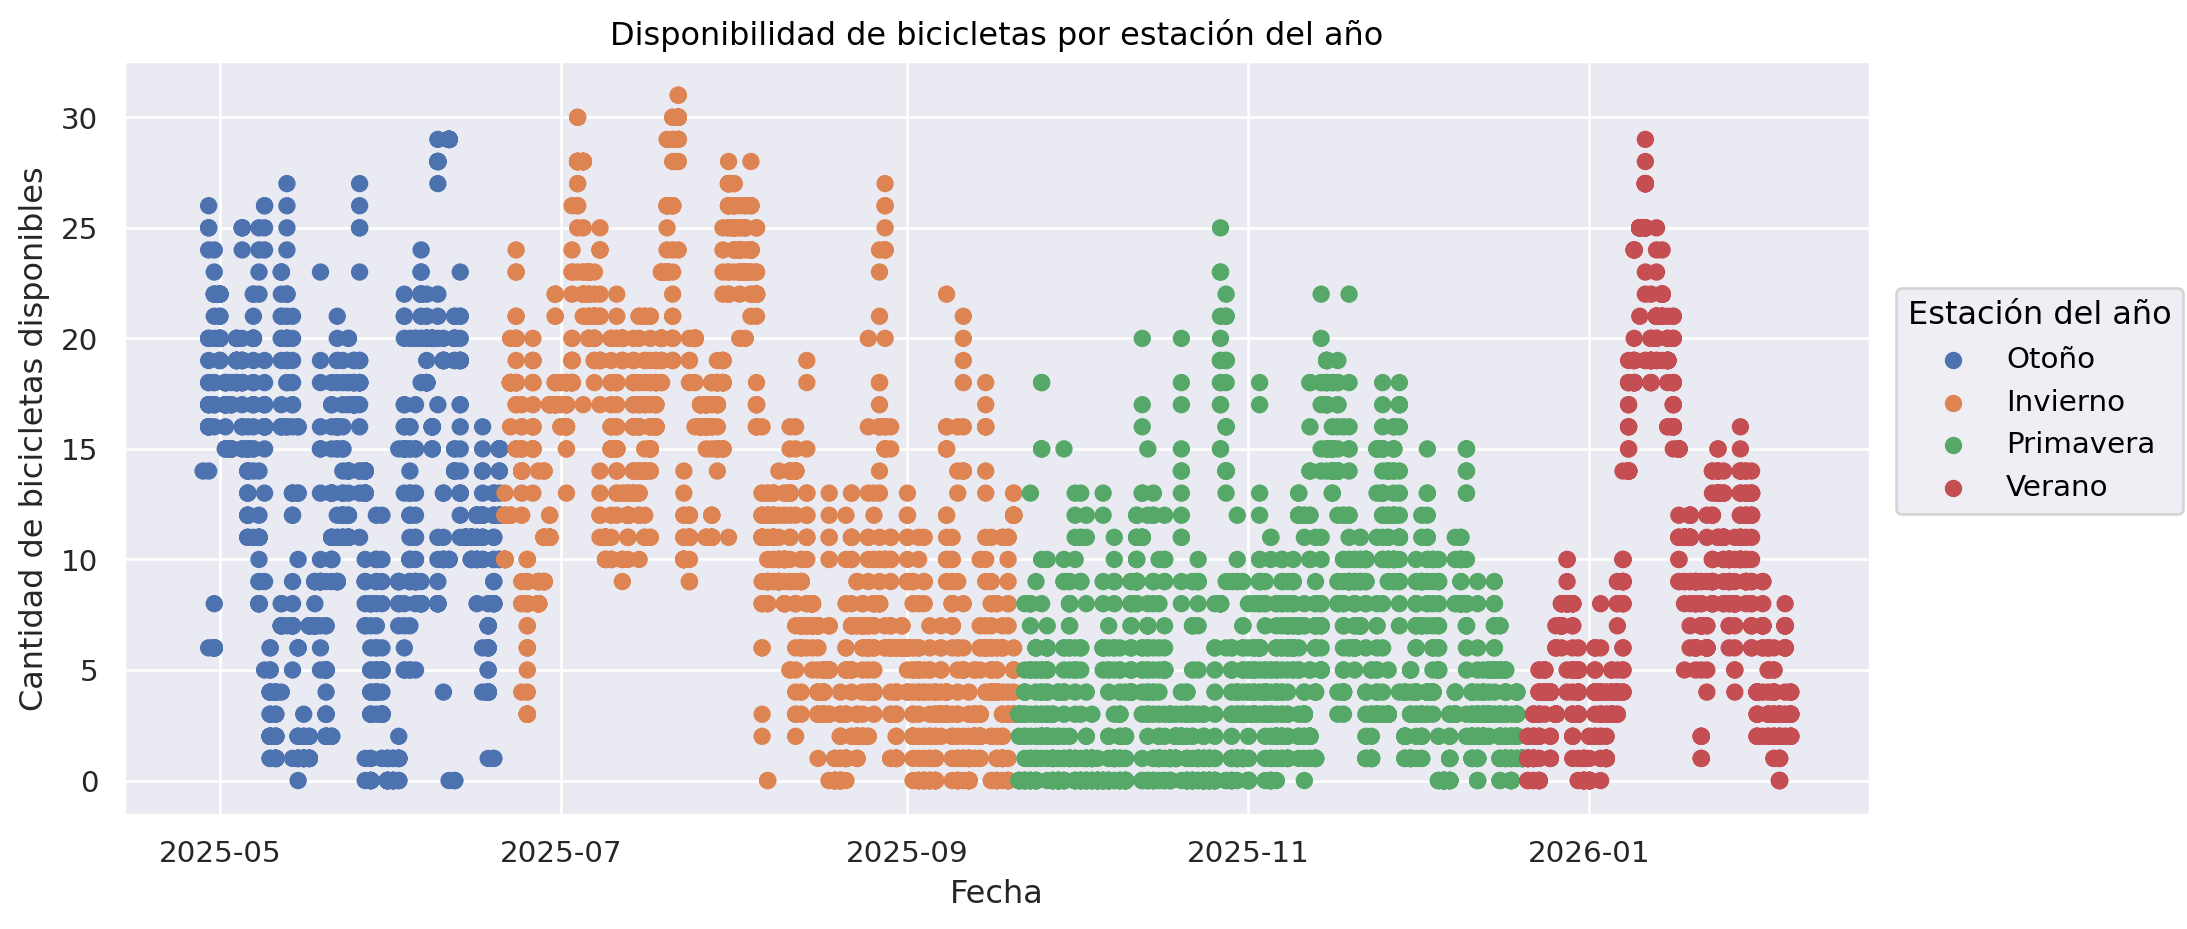

In [ ]:
(
    so.Plot(data=datos_agrupados, x="fecha", y="cantidad_bicis_disponibles", color="estacion_anio")
    .add(so.Dot())
    .label(
        title="Disponibilidad de bicicletas por estación del año",
        x="Fecha",
        y="Cantidad de bicicletas disponibles",
        color="Estación del año"
    )
    .layout(size=(10, 5))
    )


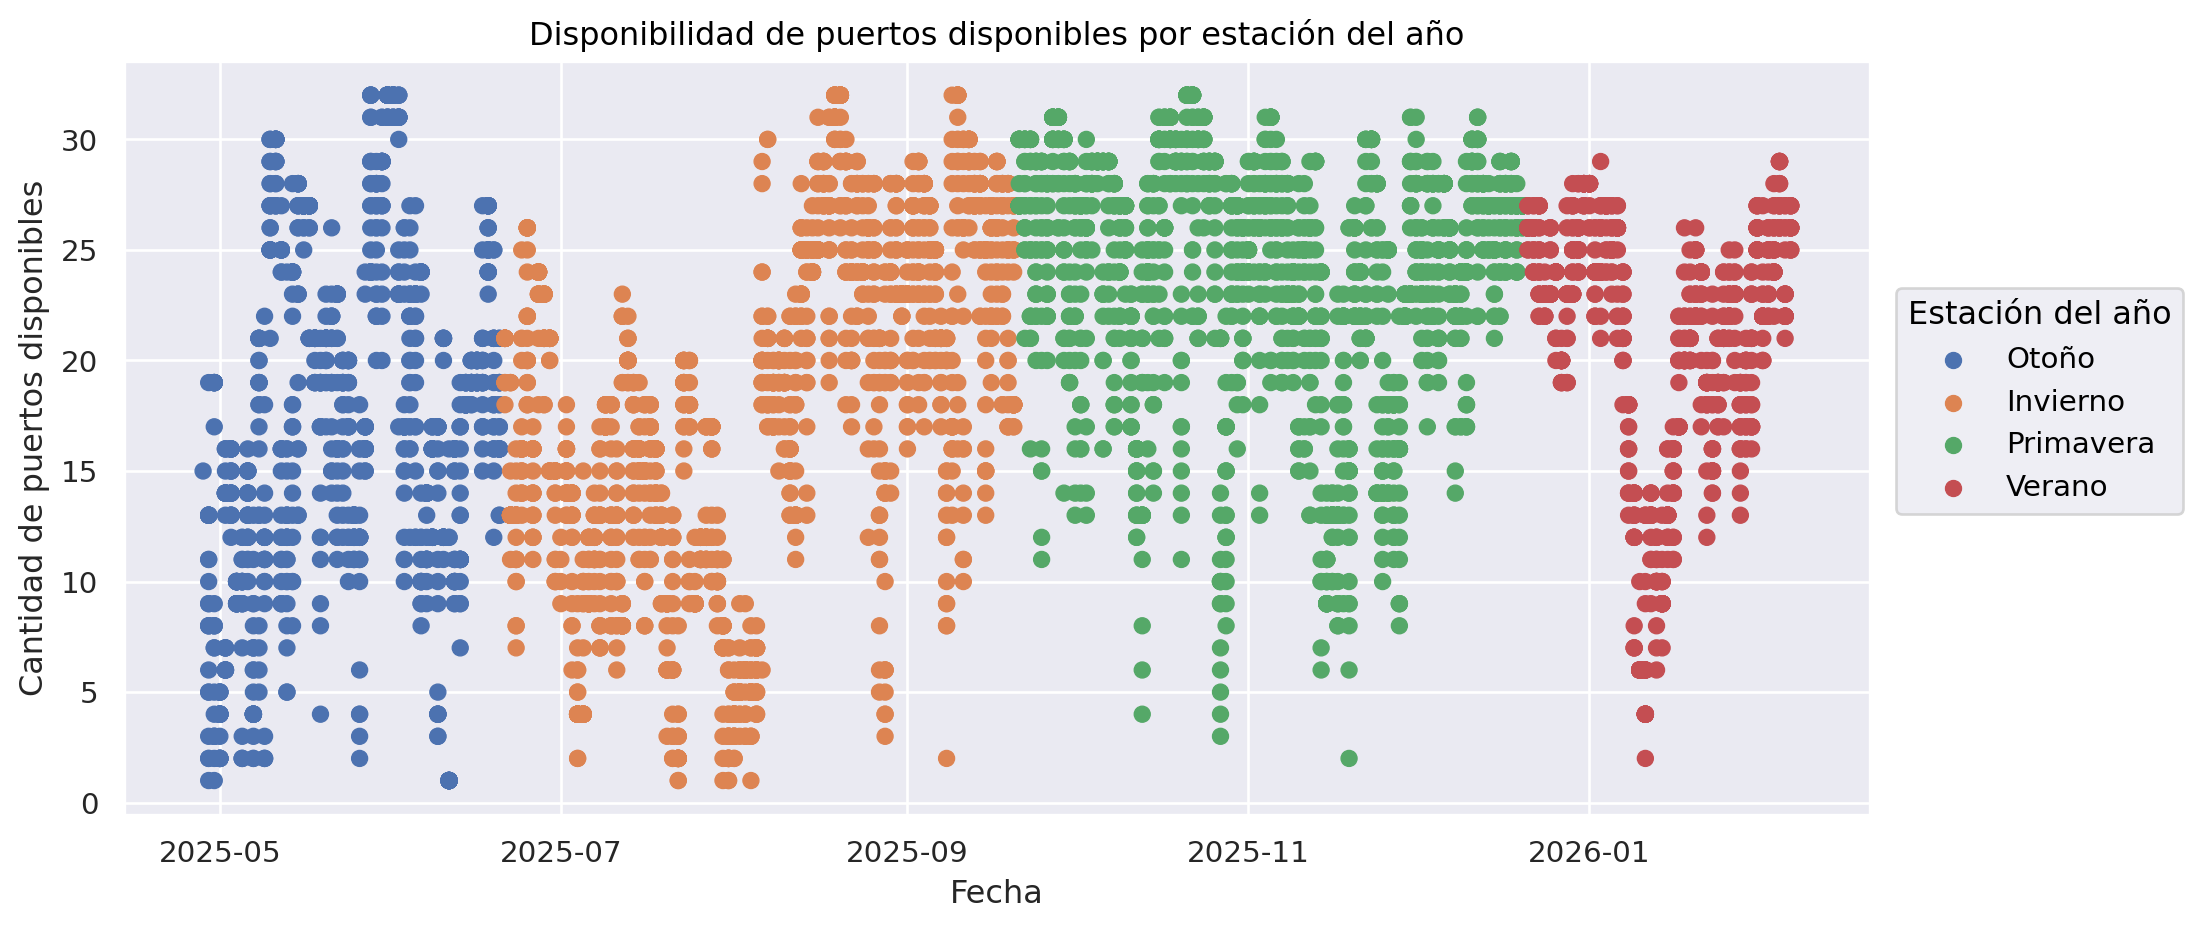

In [ ]:
(
    so.Plot(data=datos_agrupados,x="fecha",y="cantidad_puertos_disponibles",color="estacion_anio")
    .add(so.Dot())
    .label(
        title="Disponibilidad de puertos disponibles por estación del año",
        x="Fecha",
        y="Cantidad de puertos disponibles",
        color="Estación del año"
    )
    .layout(size=(10, 5))
)

Se puede observar que ambos gráficos son inversos: en las estaciones donde hay más muestras
con baja cantidad de bicis disponibles, hay alta cantidad de puertos disponibles, y viceversa.
Esto tiene sentido ya que la cantidad de puertos es fija, por lo que al aumentar las bicis
disponibles disminuyen los puertos libres.

Por ejemplo, en primavera la cantidad de bicis disponibles suele ser baja mientras que la de
puertos disponibles suele ser alta.

También se puede observar que en la primera mitad del invierno hay una cantidad alta de bicis
disponibles y baja de puertos, pero en la segunda mitad esta tendencia se invierte.

Esto podría explicarse por la temperatura: cuando hace frío la gente prefiere otros medios de
transporte, pero a medida que aumenta el calor también aumenta el uso de las bicicletas.

## Ejercicio 11

¿Cómo cambia la cantidad promedio de bicis y puertos disponibles a lo largo del día para cada día de la semana?

Para analizar esto agrupamos los datos por horas y días de la semana y luego graficamos:

In [ ]:
datos_agrupados.to_sql("datos_agrupados", con, index=False, if_exists="replace")
datos_dia_semana_hora = pd.read_sql_query(
    """SELECT hora, dia_semana,
        AVG(cantidad_bicis_disponibles) AS promedio_bicis_disponibles,
        AVG(cantidad_puertos_disponibles) AS promedio_puertos_disponibles
        FROM datos_agrupados
        GROUP BY hora, dia_semana
    """, con)
datos_dia_semana_hora.to_sql("datos_agrupados", con, index=False, if_exists="replace")

168

In [ ]:
datos_dia_semana_hora.head(3)

,hora,dia_semana,promedio_bicis_disponibles,promedio_puertos_disponibles
0,0,Domingo,8.216216,21.189189
1,0,Jueves,6.333333,22.743590
2,0,Lunes,8.947368,20.763158


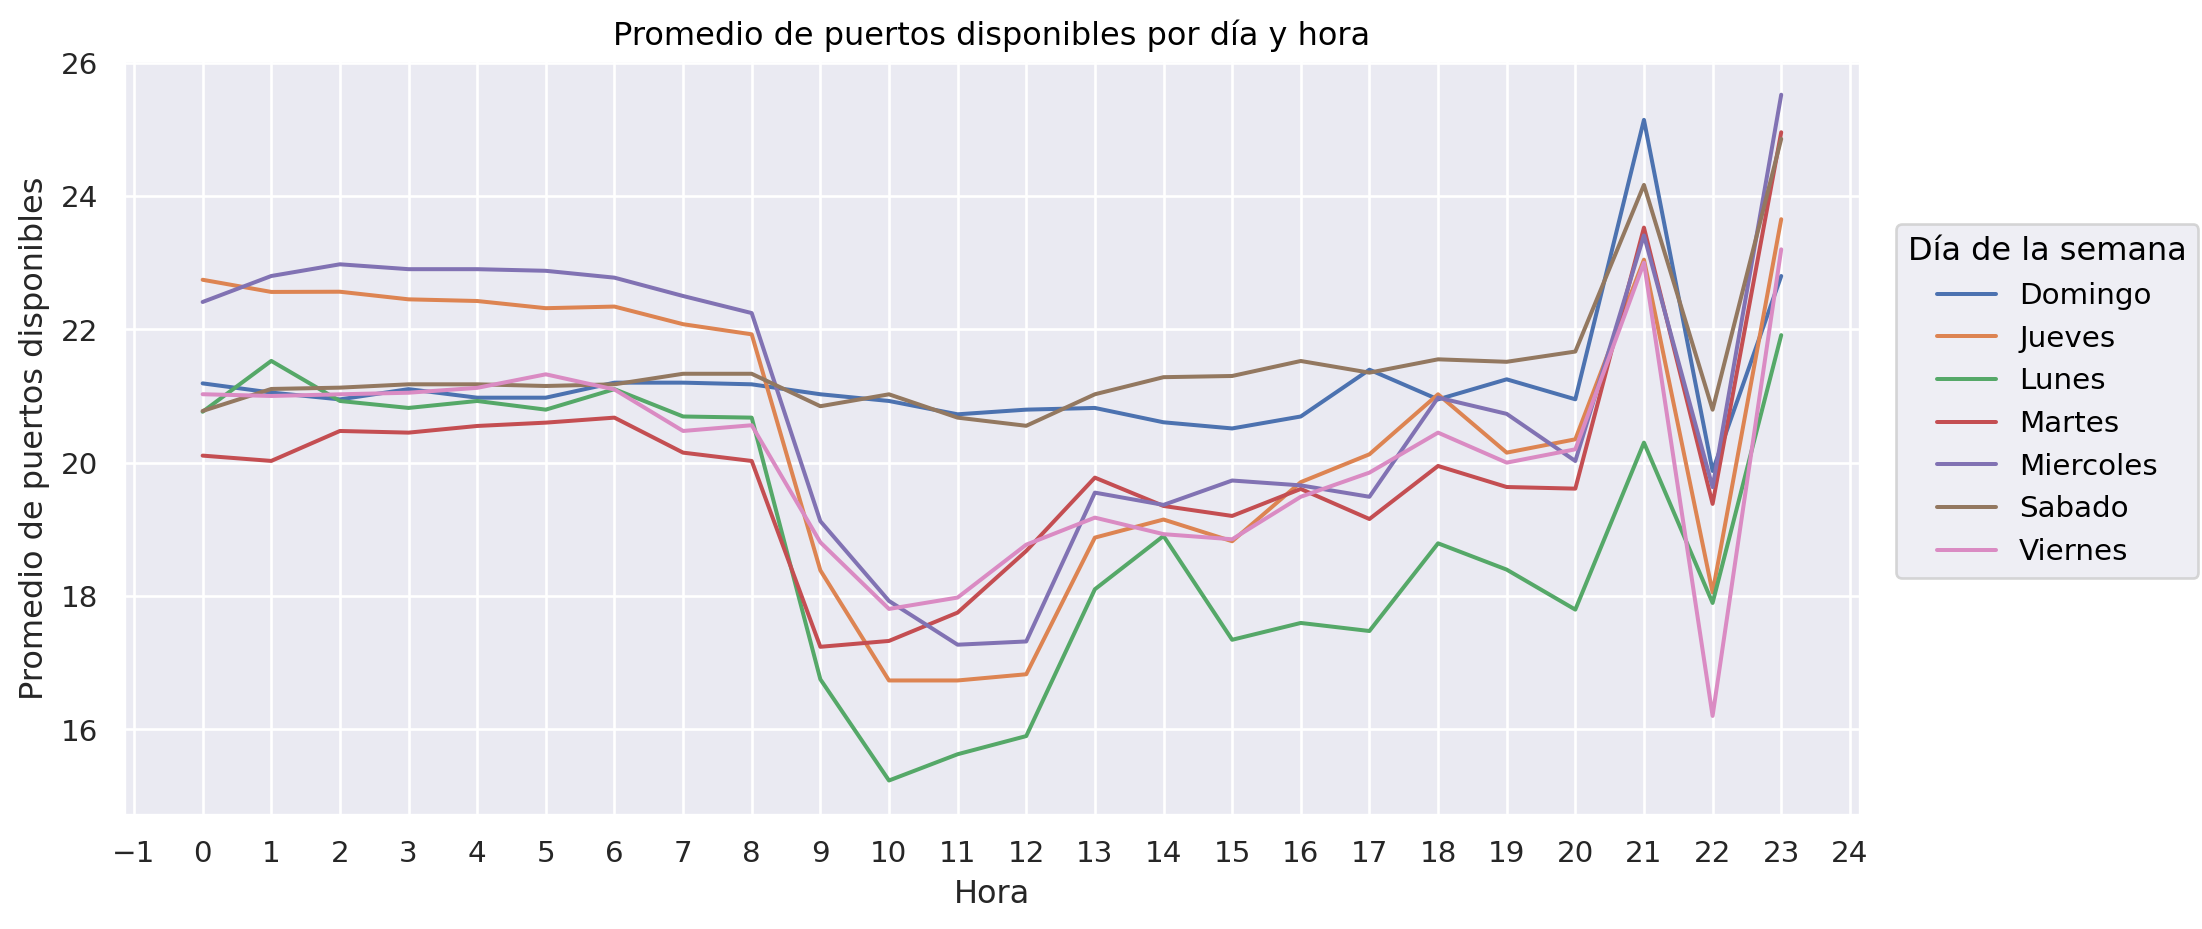

In [ ]:
(
    so.Plot(datos_dia_semana_hora,x="hora",y="promedio_puertos_disponibles",color="dia_semana")
    .add(so.Line())
    .scale(x=so.Continuous().tick(every=1))
    .label(
        title="Promedio de puertos disponibles por día y hora",
        x="Hora",
        y="Promedio de puertos disponibles",
        color="Día de la semana"
    )
    .layout(size=(10, 5))
)

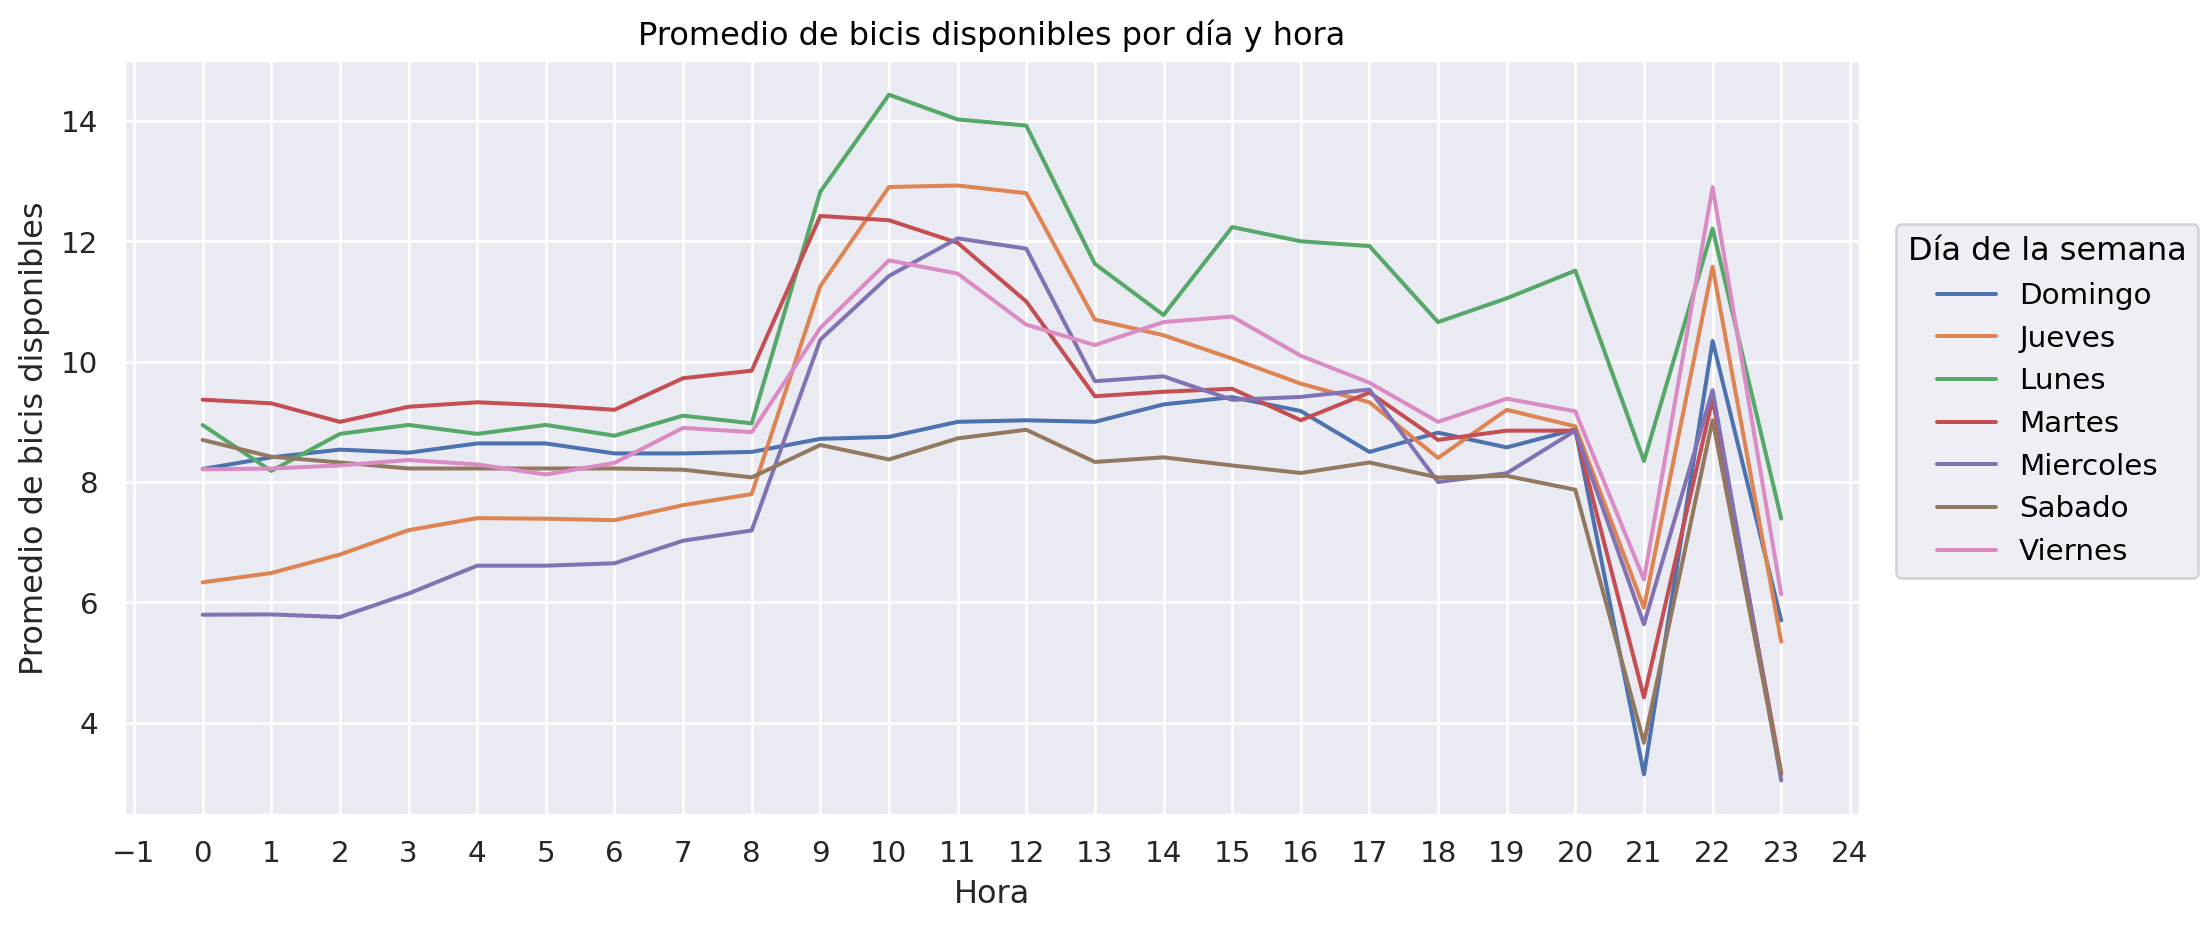

In [ ]:
(
    so.Plot(datos_dia_semana_hora,x="hora",y="promedio_bicis_disponibles",color="dia_semana")
    .add(so.Line())
    .scale(x=so.Continuous().tick(every=1))
    .label(
        title="Promedio de bicis disponibles por día y hora",
        x="Hora",
        y="Promedio de bicis disponibles",
        color="Día de la semana"
    )
    .layout(size=(10, 5))
)

Nuevamente se observa el comportamiento inverso entre los puertos y las bicis disponibles.

La cantidad de bicis disponibles aumenta durante la mañana, alcanzando su pico alrededor de
las 10-11hs, y luego disminuye gradualmente durante la tarde. Cerca de las 21hs se produce
una caída brusca seguida de una recuperación igual de pronunciada (este comportamiento se
analiza en el ejercicio 12).

Esto podría explicarse por la dinámica de Ciudad Universitaria: las bicis se acumulan en las
estaciones cuando los estudiantes llegan a la mañana, y se retiran cuando vuelven a sus casas
a la tarde.

## Ejercicio 12

En los gráficos que realizaste hay algunos valores que parezcan incorrectos o mal medidos? ¿Cómo lo podrías justificar?

Vemos que hay dos anomalías o cambios grandes en los gráficos: a las 21 y a las 23 horas. Analizamos si se debe al comportamiento de los ciclistas o a la información de nuestro dataset.

Para esto, vemos cuantos datos tenemos por hora:

In [ ]:
datos_agrupados.groupby("hora").agg(cantidad=("hora","count")).sort_values(by="cantidad",ascending=True)

,cantidad
hora,
21,125
23,141
22,154
0,269
1,275
17,276
12,276
7,277
9,277


Vemos que las horas 21 y 23 cuentan con casi la mitad de registros en comparación con el resto
de las horas. Esto podría deberse a actualizaciones del sistema o a períodos en los que las
estaciones se apagan por algún motivo, como el mantenimiento de las bicicletas. Por lo tanto,
no lo atribuimos al uso de las bicicletas sino a la forma en que se almacenan los datos.

# *Análisis exploratorio*

## Ejercicios 13 y 14

### ¿Cuáles son las semanas con mayor uso de bicis?

In [ ]:
datos_limpios["numero_semana"] = datos_limpios["fecha"].dt.isocalendar().week

In [ ]:
datos_limpios.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora,estacion_anio,numero_semana
0,420,3,1,8,0,2025-04-28,23:28:05,Lunes,2025,4,28,23,Otoño,18


/usr/local/lib/python3.12/dist-packages/seaborn/_core/groupby.py:95: FutureWarning: The provided callable <function mean at 0x7826de7b9a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data


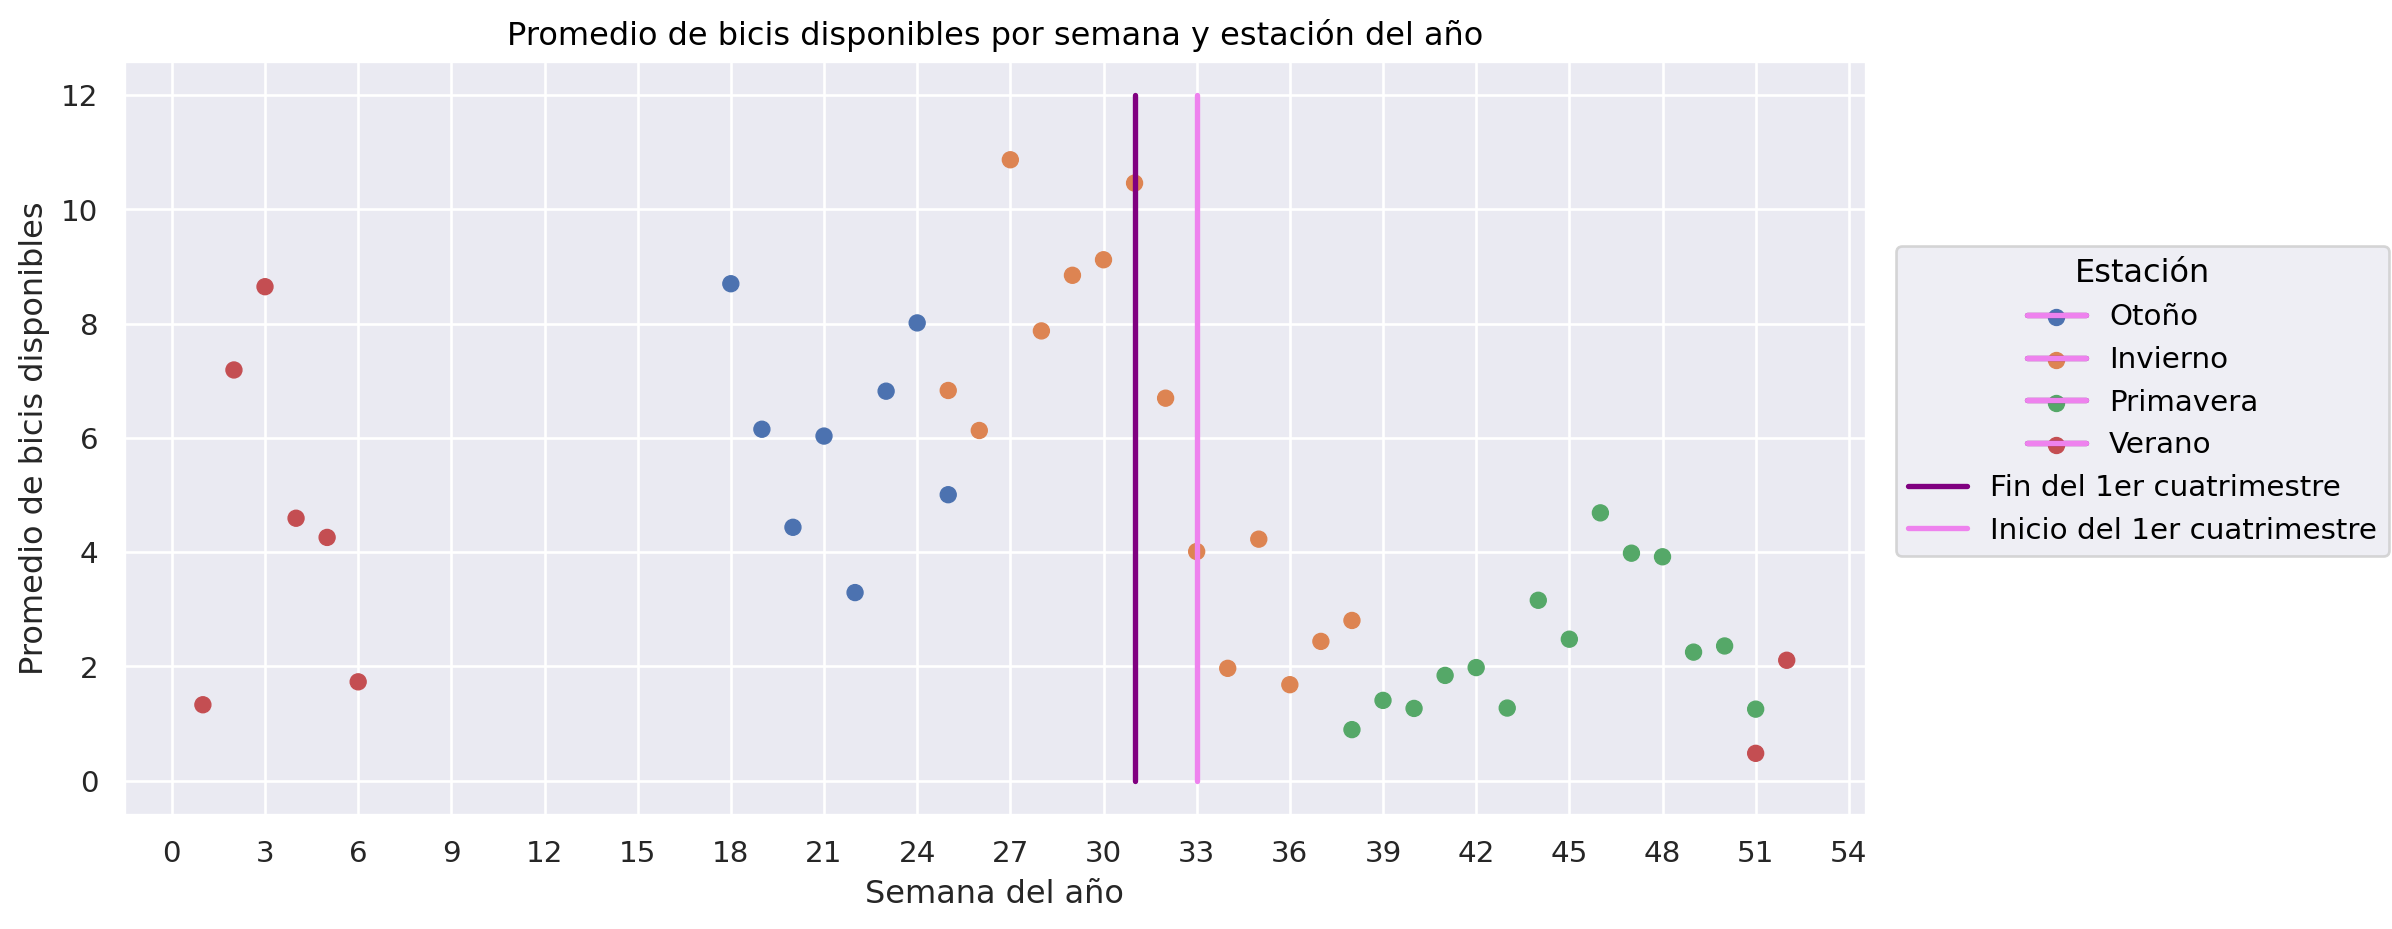

In [ ]:
vline_fin_cuat = pd.DataFrame({
    "numero_semana": [31, 31],
    "bicis_disponibles": [0,12]
})

vline_inicio_cuat = pd.DataFrame({
    "numero_semana": [33, 33],
    "bicis_disponibles": [0,12]
})

(
    so.Plot(datos_limpios,x="numero_semana",y="bicis_disponibles",color="estacion_anio")
    .add(so.Dot(), so.Agg(np.mean))
    .add(so.Line(color="purple", linewidth=2),data=vline_fin_cuat,x="numero_semana",y="bicis_disponibles",label="Fin del 1er cuatrimestre")
    .add(so.Line(color="violet", linewidth=2),data=vline_inicio_cuat,x="numero_semana",y="bicis_disponibles",label="Inicio del 1er cuatrimestre")
    .scale(x=so.Continuous().tick(every=3))
    .label(
        title="Promedio de bicis disponibles por semana y estación del año",
        x="Semana del año",
        y="Promedio de bicis disponibles",
        color="Estación"
    )
    .layout(size=(10, 5))
)

Las semanas que establecimos como fin del primer cuatrimestre e inicio del segundo no son exactas, ya que cambian para el CBC, FADU y FCEN, y despues de que termina la cursada sigue viniendo gente por las semanas de finales. De todas maneras nos dan información contextual que podría explicar la gran disminución del promedio de bicicletas disponibles entre la semana 30 y 32.

### ¿Cómo afecta el clima el uso de las bicis?

A partir del gráfico de bicis disponibles por estación del año podemos suponer que los días más cálidos (primavera y verano) aumenta el uso de bicis y los días más fríos disminuye (otoño e invierno).

Lo vemos:

In [ ]:
clima.to_sql("clima", con , index=False, if_exists="replace")
datos_con_clima = pd.read_sql_query(
    """SELECT
        datos_limpios.*,
        temp_promedio,temp_max,precipitacion_total,velocidad_viento,presion_aire
        FROM datos_limpios
        LEFT JOIN clima
        ON clima.fecha = datos_limpios.fecha
    """, con)

Este DataFrame nos va a servir para relacionar la información que tengamos de las bicicletas con la del clima

In [ ]:
datos_con_clima.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora,estacion_anio,temp_promedio,temp_max,precipitacion_total,velocidad_viento,presion_aire
0,420,3,1,8,0,2025-04-28 00:00:00,23:28:05.000000,Lunes,2025,4,28,23,Otoño,16.9,22.5,0.0,5.6,1017.5


Graficamos la cantidad de bicis disponibles en función de la temperatura promedio y coloreamos según la estación para validar o no nuestra hipótesis:

/usr/local/lib/python3.12/dist-packages/seaborn/_core/groupby.py:95: FutureWarning: The provided callable <function mean at 0x7826de7b9a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data


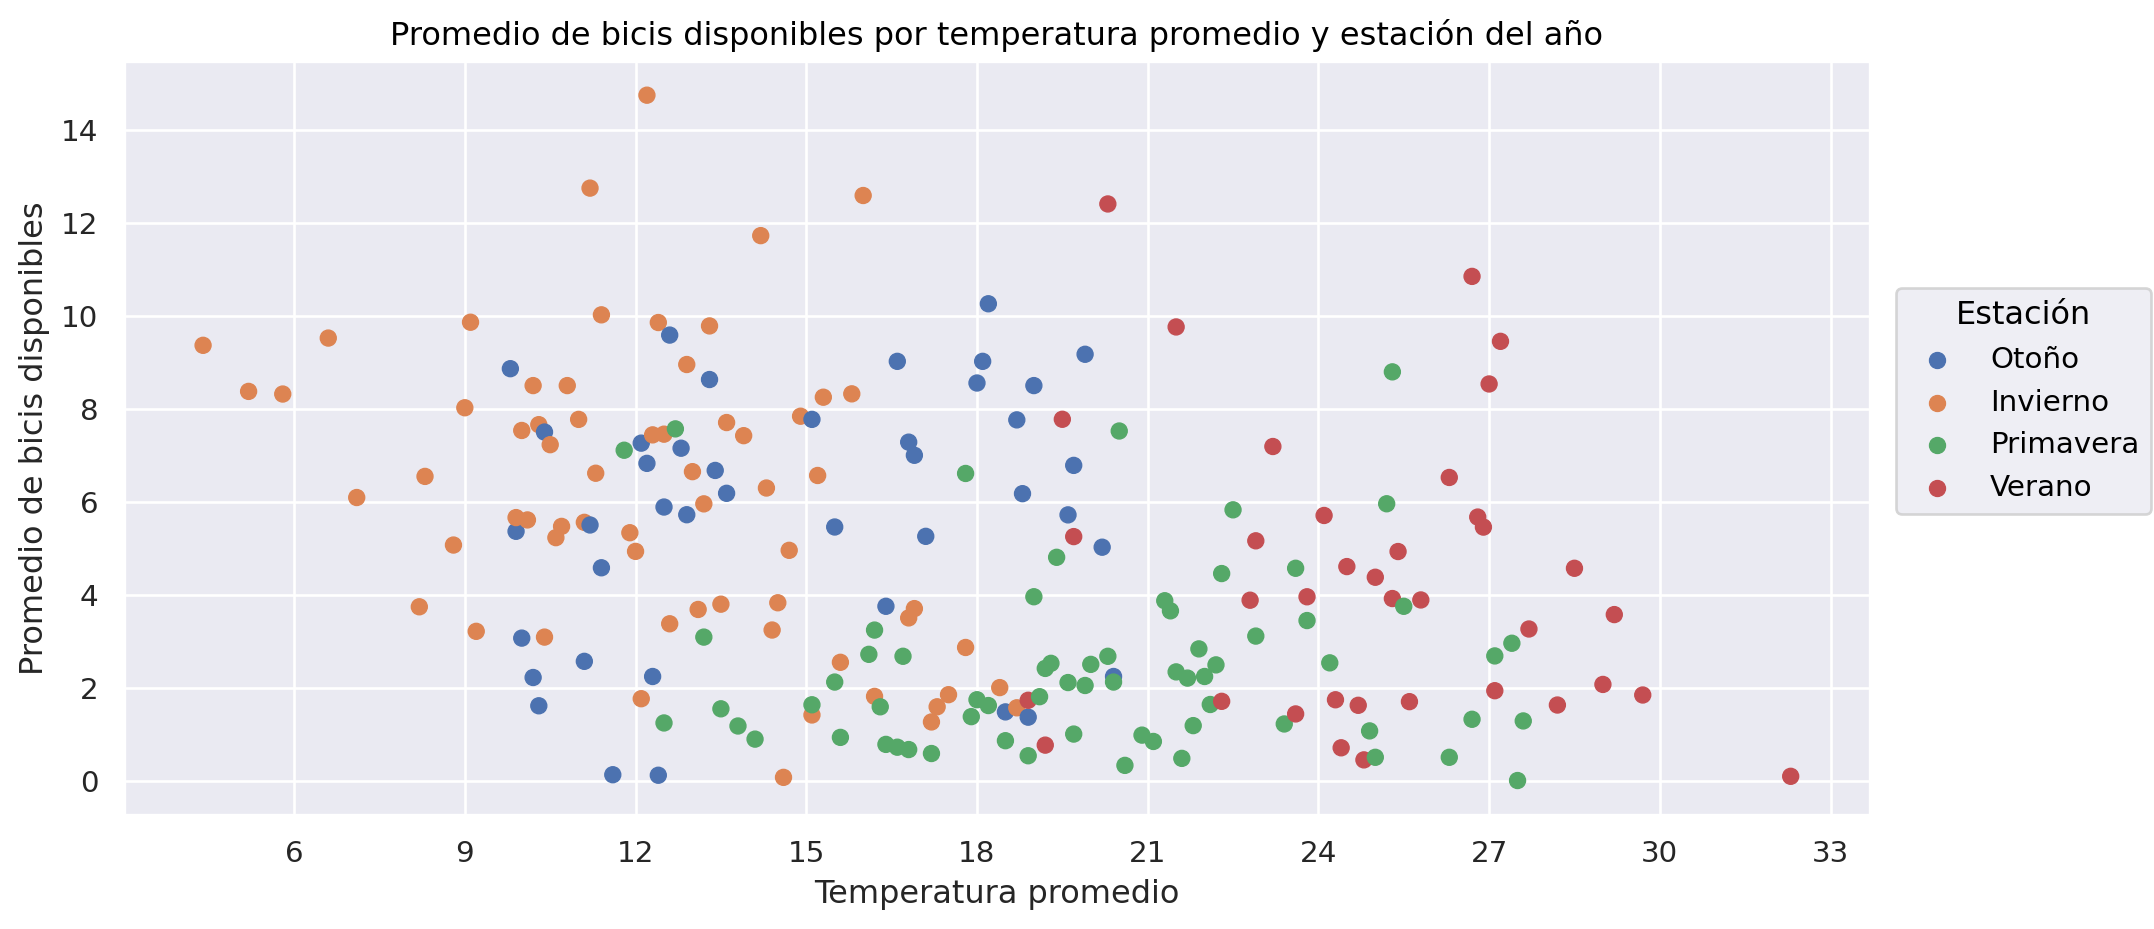

In [ ]:
(
    so.Plot(datos_con_clima,x="temp_promedio",y="bicis_disponibles",color="estacion_anio")
    .add(so.Dot(), so.Agg(np.mean))
    .scale(x=so.Continuous().tick(every=3))
    .label(
        title="Promedio de bicis disponibles por temperatura promedio y estación del año",
        x="Temperatura promedio",
        y="Promedio de bicis disponibles",
        color="Estación"
    )
    .layout(size=(10, 5))
)


Efectivamente observamos menos bicis disponibles los días de mayor temperatura promedio que también coinciden con primavera y verano, aunque no termina de ser clara la tendencia.

Quitamos el color por estación y agregamos una curva de tendencia solamente en función de la temperatura.



/usr/local/lib/python3.12/dist-packages/seaborn/_core/groupby.py:95: FutureWarning: The provided callable <function mean at 0x7826de7b9a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data


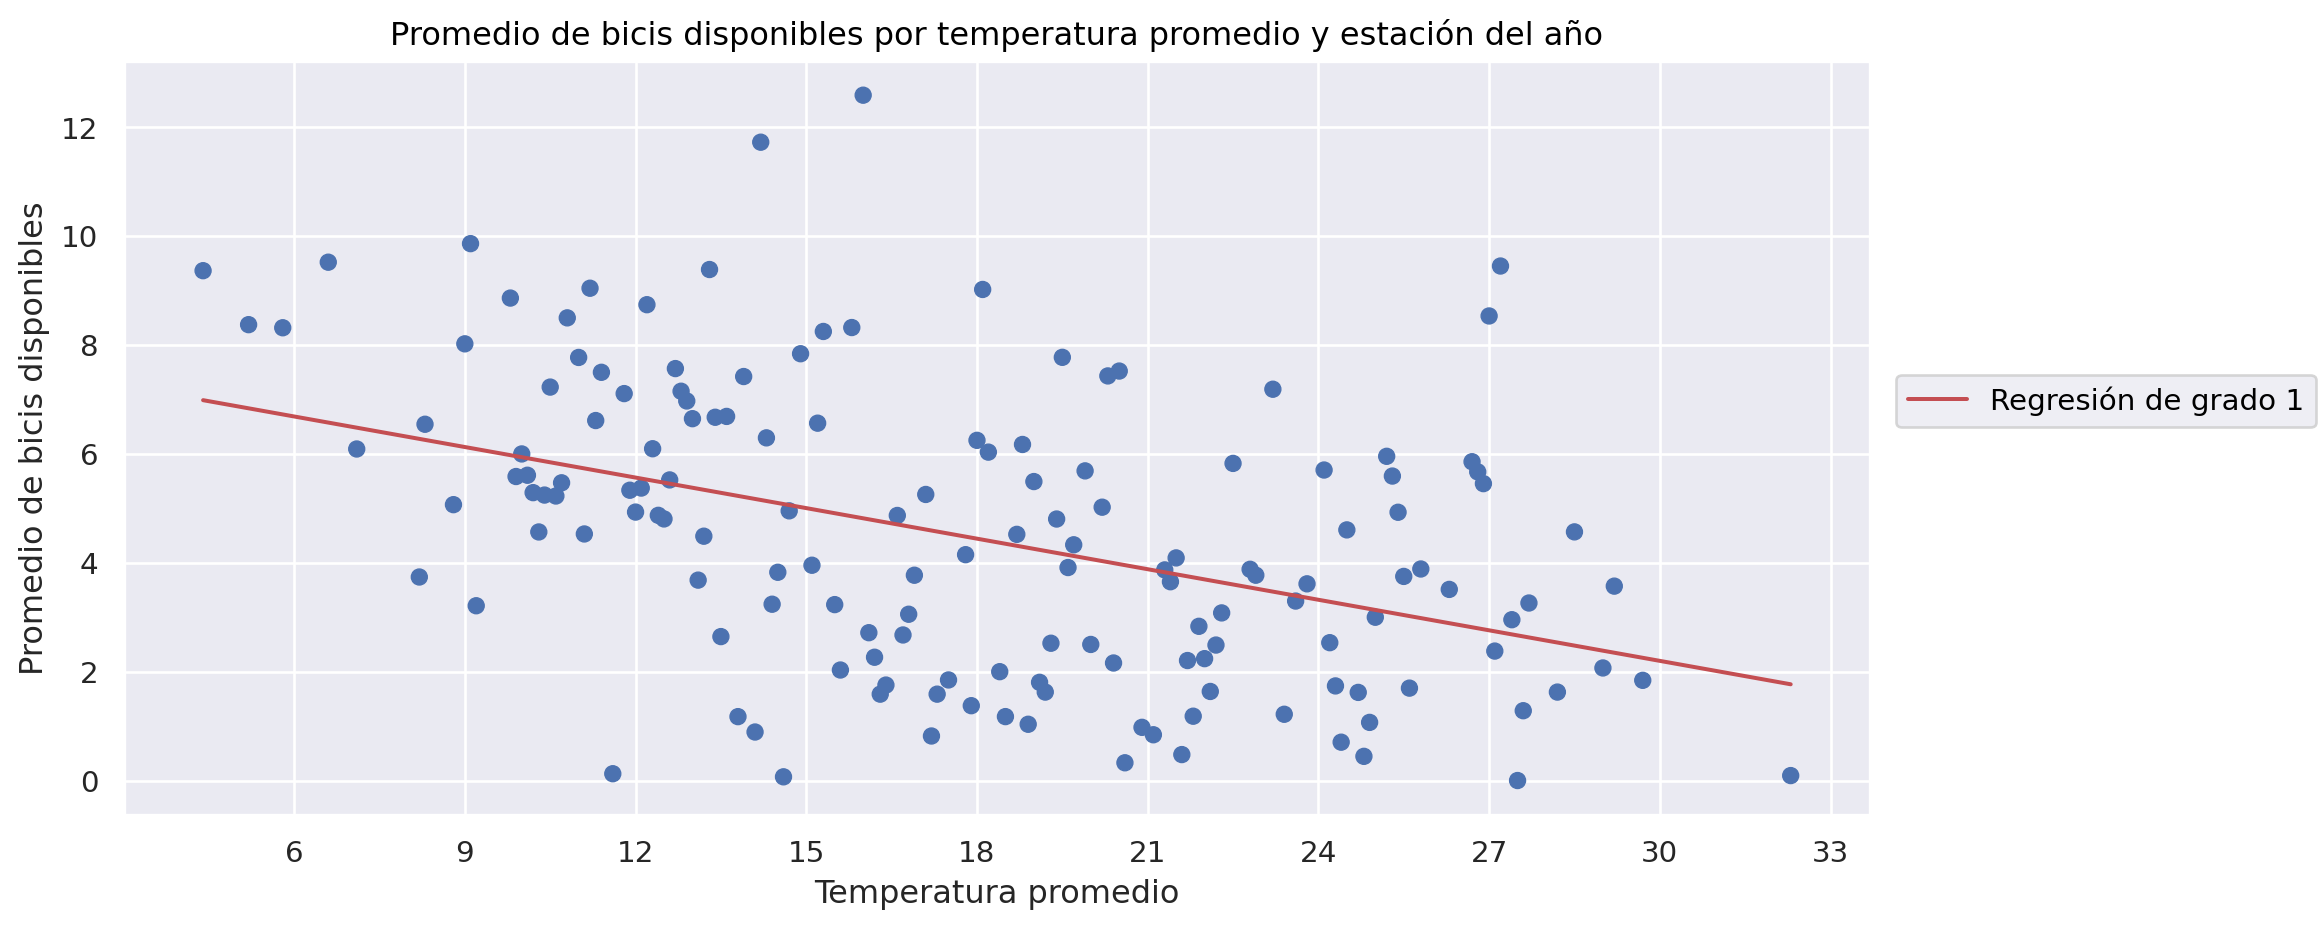

In [ ]:
(
    so.Plot(datos_con_clima, x="temp_promedio", y="bicis_disponibles")
    .add(so.Dot(), so.Agg(np.mean))
    .add(so.Line(color="r"), so.PolyFit(1),label="Regresión de grado 1")
    .scale(x=so.Continuous().tick(every=3))
    .label(
        title="Promedio de bicis disponibles por temperatura promedio y estación del año",
        x="Temperatura promedio",
        y="Promedio de bicis disponibles",
        color="Estación"
    )
    .layout(size=(10, 5))
)

Aquí se ve clara la tendencia, a mayor temperatura menor promedio de bicis disponibles y por lo tanto más bicis en uso.

Sin embargo, observamos que en casos extremos este no debería ser el comportamiento. Pues sabemos que tanto los días de mucho frio como los de mucho calor el uso de las bicis debería disminuír.

Vemos si aproximando con una parábola se ajusta mejor al comportamiento esperado:

/usr/local/lib/python3.12/dist-packages/seaborn/_core/groupby.py:95: FutureWarning: The provided callable <function mean at 0x7826de7b9a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data


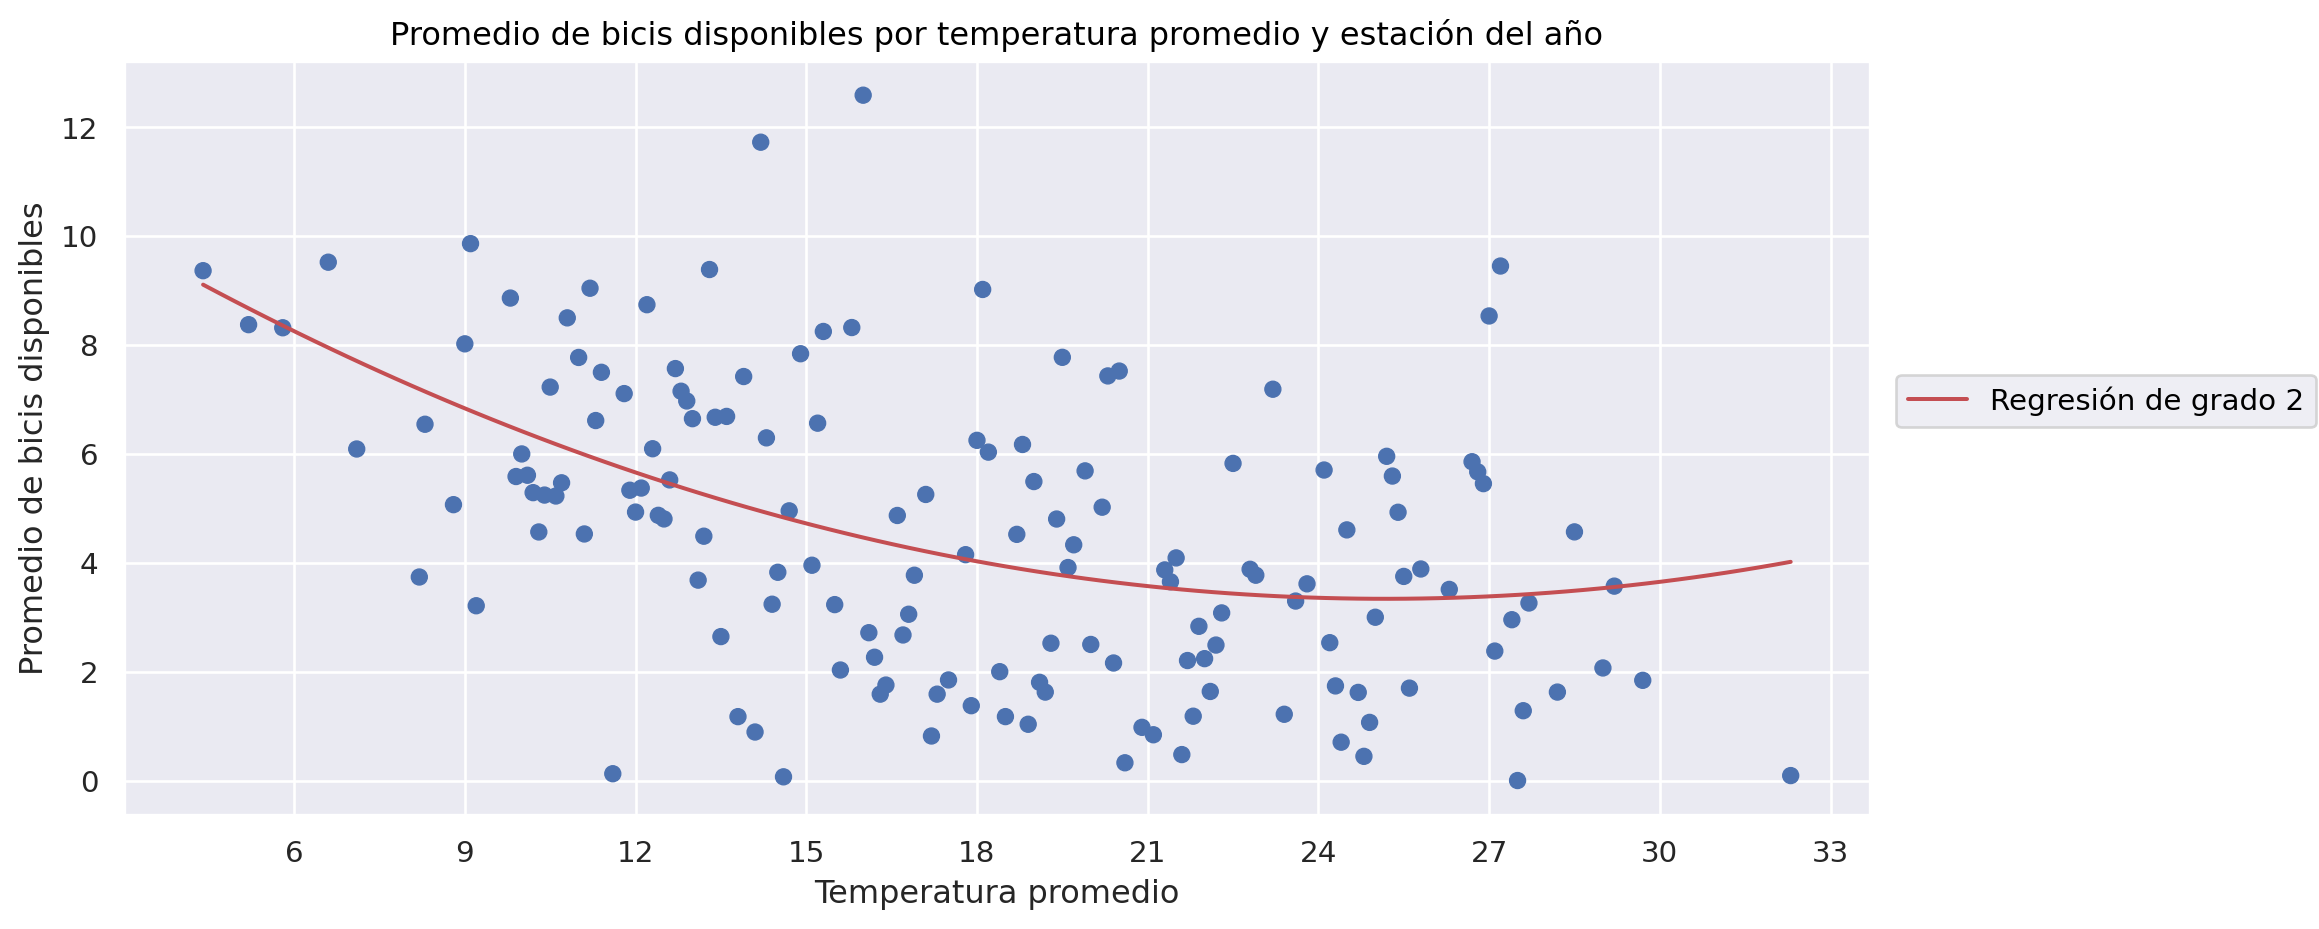

In [ ]:
(
    so.Plot(datos_con_clima, x="temp_promedio", y="bicis_disponibles")
    .add(so.Dot(), so.Agg(np.mean))
    .add(so.Line(color="r"), so.PolyFit(2),label="Regresión de grado 2")
    .scale(x=so.Continuous().tick(every=3))
    .label(
        title="Promedio de bicis disponibles por temperatura promedio y estación del año",
        x="Temperatura promedio",
        y="Promedio de bicis disponibles",
        color="Estación"
    )
    .layout(size=(10, 5))
)

Ahora sí, vemos que las bicis disponibles aumentan en temperaturas extremas y disminuyen en temperaturas moderados, de manera inversa al uso de las mismas.

### Bicis Rotas

Ahora vamos a analizar que pasa con las bicis rotas, separamos el dataset "datos_limpios" en dos: uno para cada estación, y vemos como evoluciona la cantidad de bicis rotas para cada muestra.

In [ ]:
datos_limpios["estacion"].unique()

array([420, 464])

Podemos ver que solamente hay dos estaciones

Queremos usar los datos de cada estación agrupados por hora, para ver que ocurre con las bicis rotas con el transcurso del dia

In [ ]:
datos_estacion_420 = datos_limpios[datos_limpios["estacion"]==420].groupby("hora")[["bicis_disponibles","bicis_rotas"]].mean()
datos_estacion_464 = datos_limpios[datos_limpios["estacion"]==464].groupby("hora")[["bicis_disponibles","bicis_rotas"]].mean()

In [ ]:
display(datos_estacion_420.head(3))
display(datos_estacion_464.head(3))

,bicis_disponibles,bicis_rotas
hora,,
0,2.092937,1.245353
1,2.112727,1.276364
2,2.215054,1.204301


,bicis_disponibles,bicis_rotas
hora,,
0,5.836431,1.382900
1,5.701818,1.312727
2,5.706093,1.272401


Graficamos la cantidad de bicis rotas en función de la hora para las dos estaciones en un mismo gráfico

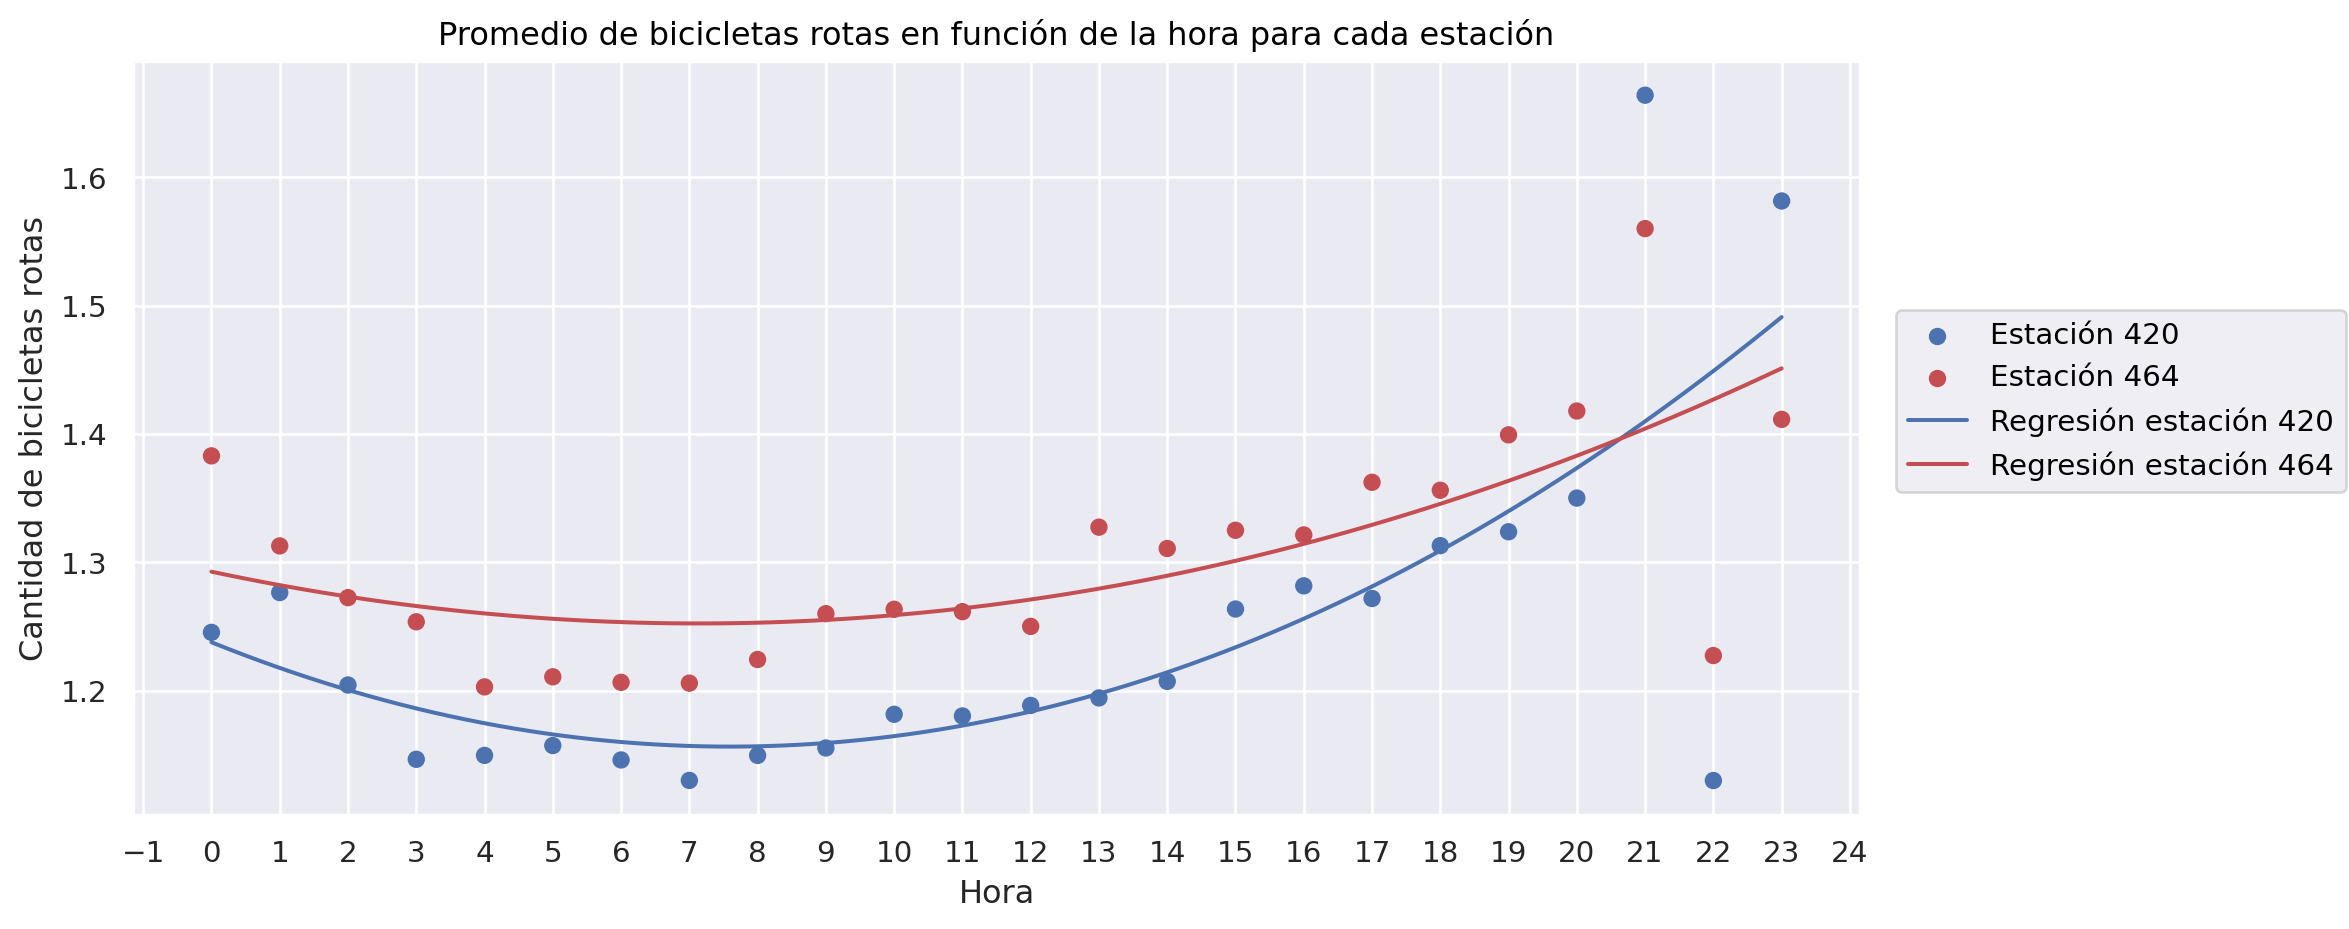

In [ ]:
df_bicis_rotas_420 = pd.DataFrame({
    "hora": datos_estacion_420.index,
    "bicis": datos_estacion_420["bicis_rotas"]})

df_bicis_rotas_464 = pd.DataFrame({
    "hora": datos_estacion_464.index,
    "bicis": datos_estacion_464["bicis_rotas"]})

(
    so.Plot()
    .add(so.Dot(color="b"),data=df_bicis_rotas_420, x="hora", y="bicis",label="Estación 420")
    .add(so.Dot(color="r"),data=df_bicis_rotas_464, x="hora", y="bicis",label="Estación 464")
    .add(so.Line(color="b"), so.PolyFit(2), data=df_bicis_rotas_420, x="hora", y="bicis", label="Regresión estación 420")
    .add( so.Line(color="r"), so.PolyFit(2), data=df_bicis_rotas_464, x="hora", y="bicis", label="Regresión estación 464")
    .scale(x=so.Continuous().tick(every=1))
    .label(
        title="Promedio de bicicletas rotas en función de la hora para cada estación",
        x="Hora",
        y="Cantidad de bicicletas rotas",
    )
    .layout(size=(10, 5))
)

Podemos concluir que cerca de la madrugada, entre las 0 y 3 hs, disminuye la cantidad de bicicletas rotas, por lo que se puede suponer que se arreglan o se retiran una gran cantidad.

Durante el día no parece que se arreglen o retiren (excepto a las 5 y 16 hs), ya que se nota una clara tendencia del aumento de bicis rotas hasta las 21 hs.

A las 5 y las 16 hs se podría pensar que se sacan o arreglan algunas, ya que hay una leve disminución de bicicletas rotas.

Los datos que se ven entre las 21 y 23 hs (que tienen variaciones grandes ), se pueden explicar de la misma forma que para el gráfico anterior que enseñaba la cantidad de bicicletas disponibles segun la hora para cada día de la semana. La explicación es que en ese rango horario, hay muchos menos datos que para el resto de horarios, por lo que va a ser mas sensible frente a cambios.

Ambas estaciones tienen un comportamiento similar: a la madrugada un comportamiento decreciente, y con el avance del dia creciente.

### Uso de bicis según la estación

Graficamos la cantidad de bicis disponibles en función de la hora para las dos estaciones en un mismo gráfico

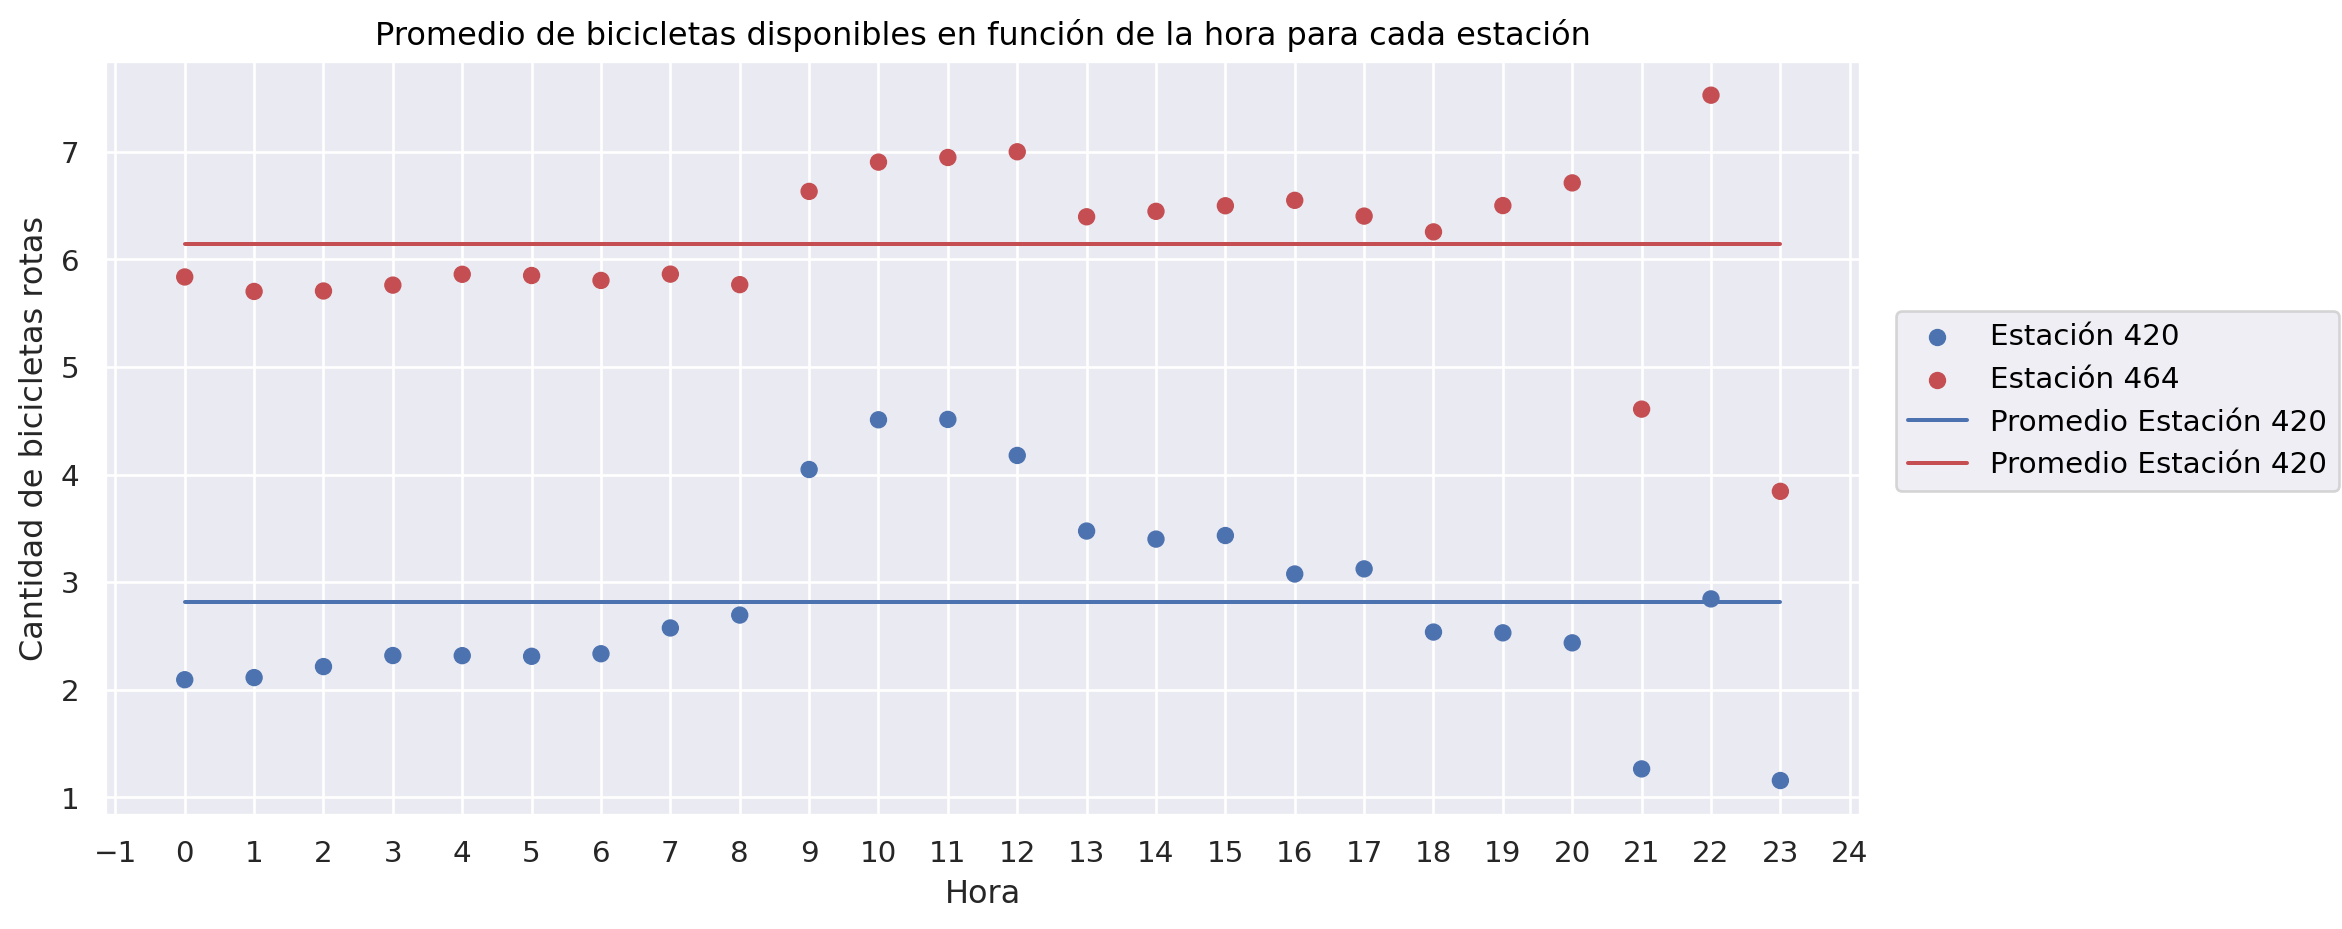

In [ ]:
mean_420 = datos_estacion_420['bicis_disponibles'].mean()
mean_464 = datos_estacion_464['bicis_disponibles'].mean()

(
    so.Plot(x=datos_estacion_464.index)
    .add(so.Dot(color="b"),y=datos_estacion_420['bicis_disponibles'],label="Estación 420")
    .add(so.Dot(color="r"),y=datos_estacion_464['bicis_disponibles'],label="Estación 464")
    .add(so.Line(color="b"),y=[mean_420] * len(datos_estacion_420),label="Promedio Estación 420")
    .add(so.Line(color="r"),y=[mean_464] * len(datos_estacion_464),label="Promedio Estación 420")
    .scale(x=so.Continuous().tick(every=1))
    .label(
        title="Promedio de bicicletas disponibles en función de la hora para cada estación",
        x="Hora",
        y="Cantidad de bicicletas rotas",
    )
    .layout(size=(10, 5))
)

Se puede ver que ambas estaciones tienen una tendencia muy similar respecto a la disponibilidad de las bicicletas, pero en promedio la estación 464 tiene aproximadamente 3 bicicletas más disponibles que la estación 420.

A simple vista parece que ambas tienen un desvio estandar similar, aunque la estación 420 parece tener un desvío un poco mayor. Esto puede deberse a que esta estación tiene más movimiento y la otra es más estable, en proporcion llegan y se van más bicicletas que en la estación 464.

In [ ]:
datos_con_clima.head(1)

,estacion,bicis_disponibles,bicis_rotas,puertos_disponibles,puertos_rotos,fecha,horario,dia_semana,anio,mes,dia,hora,estacion_anio,temp_promedio,temp_max,precipitacion_total,velocidad_viento,presion_aire
0,420,3,1,8,0,2025-04-28 00:00:00,23:28:05.000000,Lunes,2025,4,28,23,Otoño,16.9,22.5,0.0,5.6,1017.5


### Uso de bicis durante el fin de semana

Vamos a ver como varía el uso de bicicletas, comparando la disponibilidad durante la semana y el fin de semana.

Esto ya se analizó en el primer gráfico de la sección, pero queremos ver los datos de forma agrupada para poder sacar conclusiones.

In [ ]:
bicis_disponibles_semana = (
    datos_limpios[datos_limpios["dia_semana"].isin(["Lunes","Martes","Miercoles","Jueves","Viernes"])]
    .groupby("hora")["bicis_disponibles"].mean()
)

bicis_disponibles_fin_semana = (
    datos_limpios[datos_limpios["dia_semana"].isin(["Sabado","Domingo"])]
    .groupby("hora")["bicis_disponibles"].mean()
)


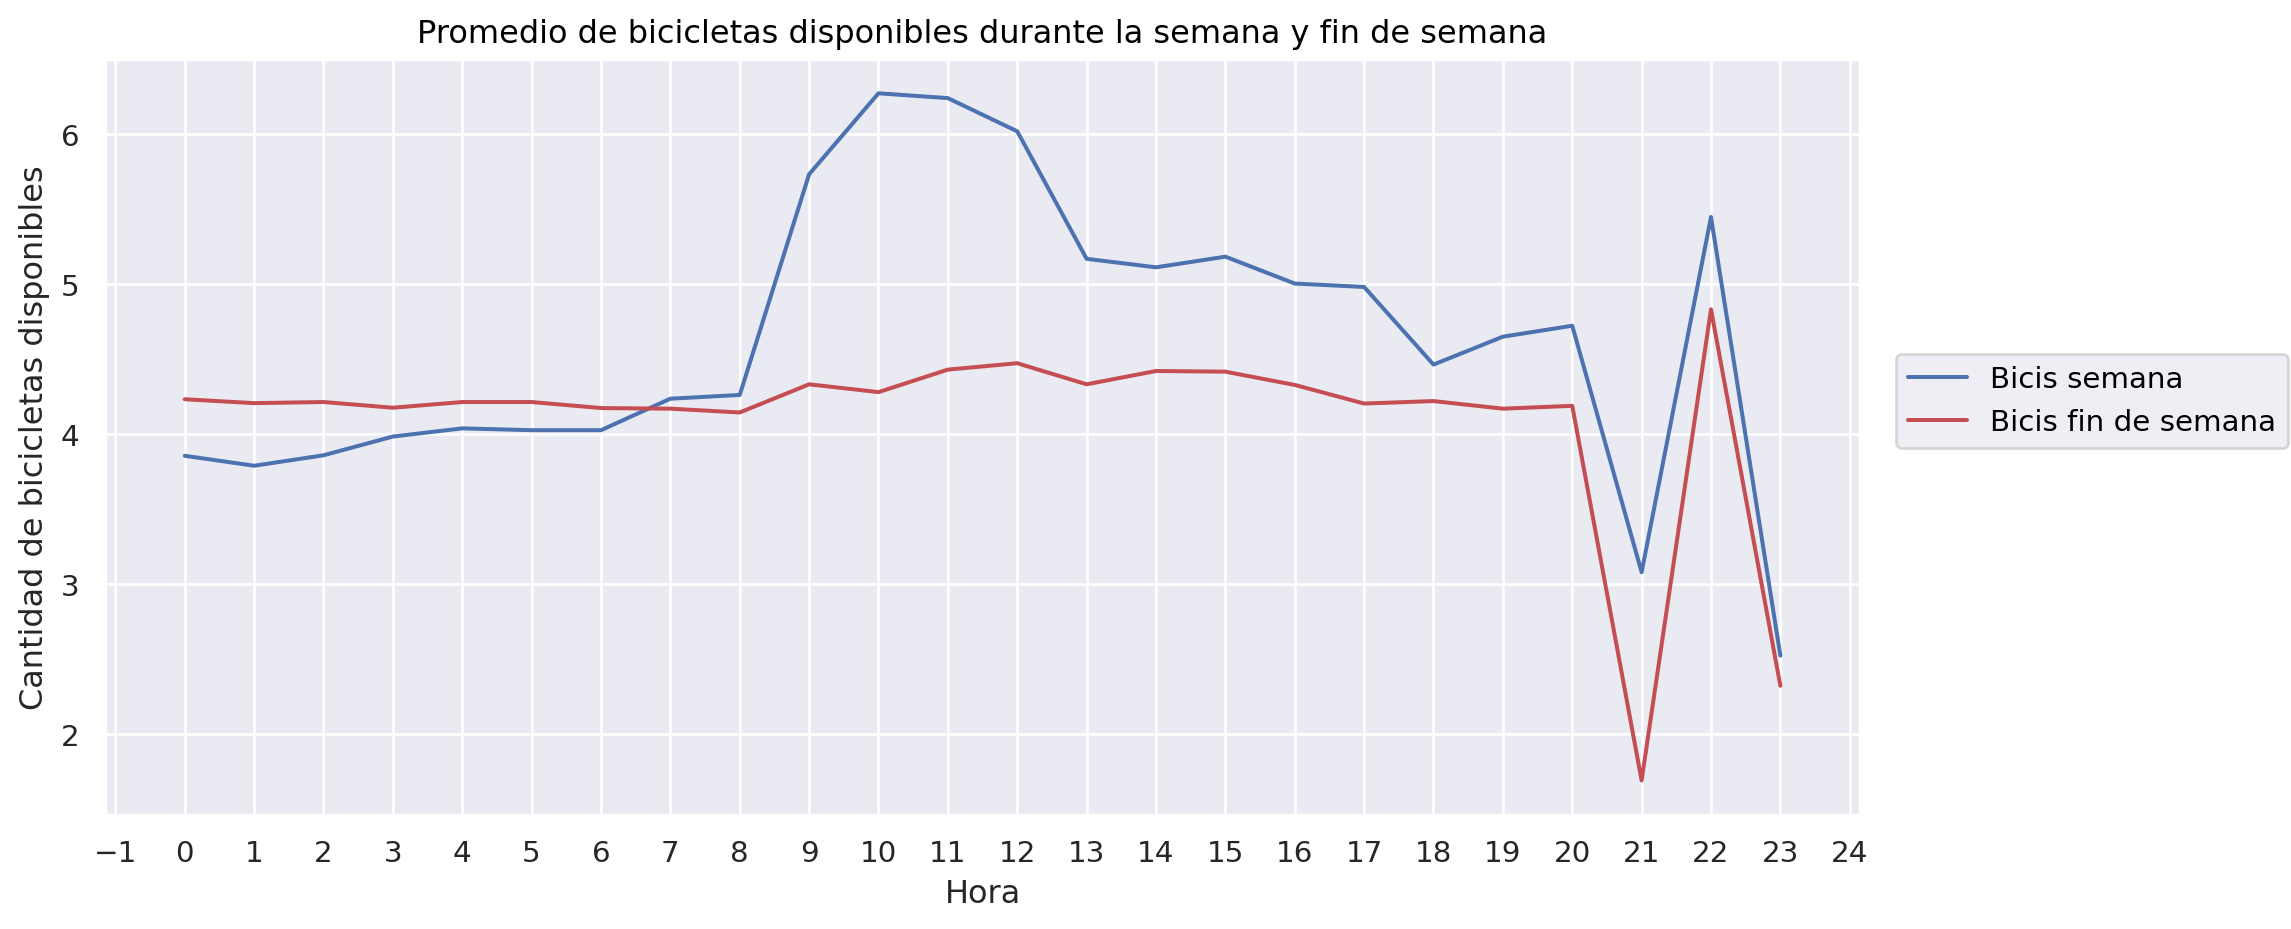

In [ ]:
df_semana = pd.DataFrame({
    "hora": bicis_disponibles_semana.index,
    "bicis": bicis_disponibles_semana.values
})

df_finde = pd.DataFrame({
    "hora": bicis_disponibles_fin_semana.index,
    "bicis": bicis_disponibles_fin_semana.values
})

(
    so.Plot()
    .add(so.Line(color="b"), data=df_semana, x="hora", y="bicis", label="Bicis semana")
    .add(so.Line(color="r"),data=df_finde, x="hora", y="bicis", label="Bicis fin de semana")
    .scale(x=so.Continuous().tick(every=1))
    .label( title="Promedio de bicicletas disponibles durante la semana y fin de semana", x="Hora", y="Cantidad de bicicletas disponibles",)
    .layout(size=(10, 5))
)

Observamos que la disponibilidad de bicicletas durante el fin de semana practicamente no varía a lo largo del dia. Esto puede deberse a un uso menor de las bicicletas por una menor circulación de gente en Ciudad Universitaria.

El comportamiento entre las 21 y 23 ya fue explicado.

### Variación del uso de bicis según el aumento de precios del transporte público / IPC

También consideramos como hipótesis el aumento del uso de bicis a raíz del aumento de los precios del transporte, o del aumento de costo de vida en general (IPC).

Sin embargo, consideramos que la información del uso de bicis disponible no abarca un período de tiempo lo suficientemente grande como para poder analizar si esta correlación verdaderamente existe, y la variación se puede deber más a otros factores, como por ejemplo al clima a lo largo del año, hipótesis que ya analizamos previamente.

# *Regresión Lineal*

## Ejercicio 15

In [ ]:
viajes_diarios.head(1)

,fecha,origen_2,origen_3,origen_4,origen_5,origen_6,origen_7,origen_8,origen_9,origen_12,...,destino_567,destino_568,destino_569,destino_570,destino_572,destino_573,destino_574,destino_575,destino_576,destino_577
0,2024-01-01,13,24,39,45,0,27,28,32,20,...,0,0,0,0,0,0,0,0,0,0


Usamos model_matrix en vez de formula (del modulo formulaic) porque no nos dejaba elegir todas las columnas con "."

In [ ]:
formula_0 = "origen_5 ~ . - origen_5 - fecha - 1"
y, X = model_matrix(formula_0, viajes_diarios)
y=y.iloc[:,0]

Excluimos la fecha porque creaba una variable (con 0 o 1) para cada valor distinto de fecha, y todas las filas tienen fechas distintas, por lo que no aportaba nada de información.

In [ ]:
modelo_0 = linear_model.LinearRegression(fit_intercept=True)
modelo_0.fit(X,y)

y_pred = modelo_0.predict(X)

print('R^2: ', r2_score(y, y_pred))
print("RECM: ", np.sqrt(mean_squared_error(y, y_pred)))

R^2:  1.0
RECM:  3.401597574023664e-13


Este resultado (que la recta ajuste perfectamente, ya que R2=1) era esperable, ya que se tenian 366 filas y 794 columnas, por lo que hay un overfitting que hace que el modelo ajuste los datos de forma exacta, pero si se quisiera evaluar con datos nuevos el modelo probablemente no seria tan eficaz.

In [ ]:
columnas_coeficientes = pd.DataFrame({"columnas":X.columns,"coeficientes":modelo_0.coef_})
columnas_coeficientes = columnas_coeficientes.sort_values(by="coeficientes",ascending=False)

In [ ]:
columnas_coeficientes.head()

,columnas,coeficientes
397,destino_5,0.732009
626,destino_370,0.215631
540,destino_219,0.196235
250,origen_407,0.191460
548,destino_231,0.187102


Las columnas que tienen mayor coeficiente son las que mas sirven para predecir el valor de "origen_5"

## Ejercicio 16

Graficamos la cantidad de bicicletas usando origen_5 y destino_5, ya que esta última es la variable que mejor explica la que queremos predecir (según los coeficientes obtenidos).

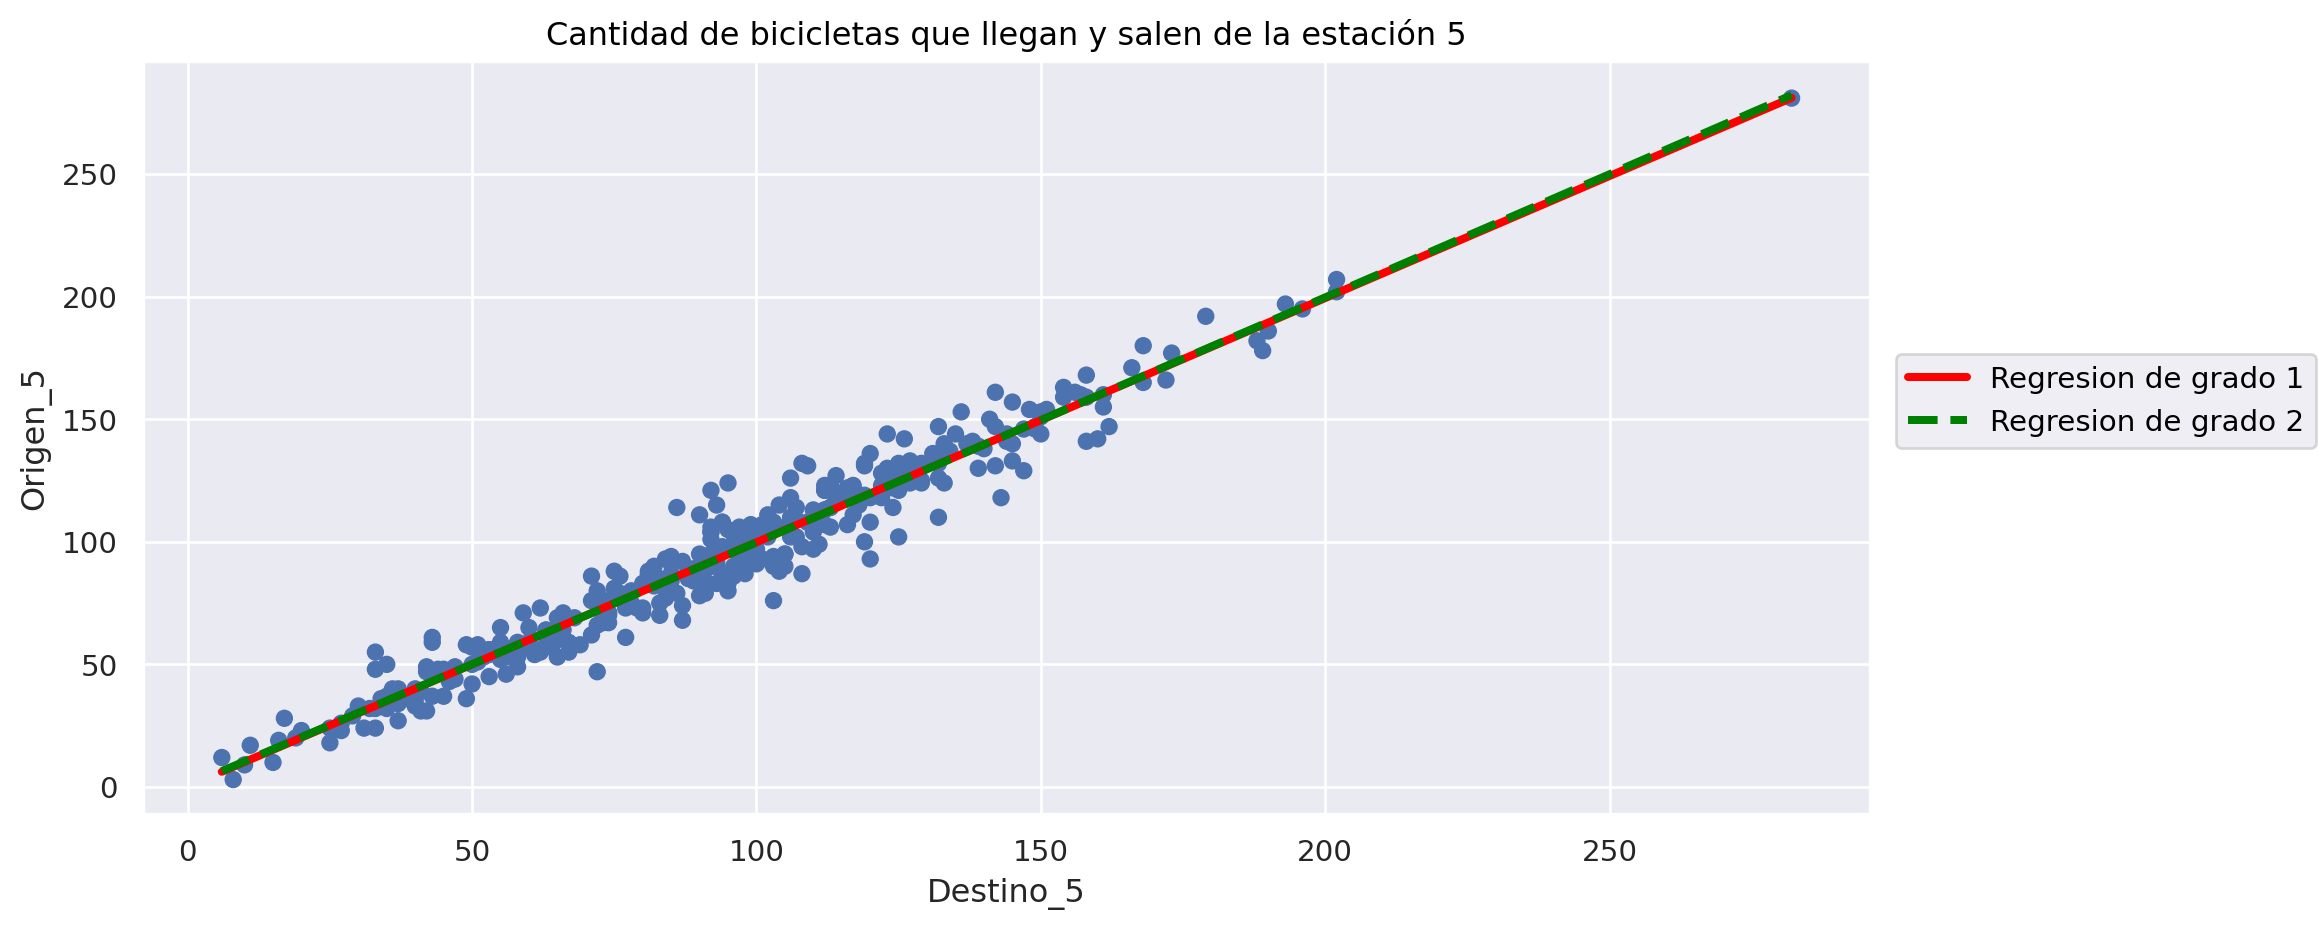

In [ ]:
(
    so.Plot(data=viajes_diarios,x="destino_5",y="origen_5")
    .add(so.Dot())
    .add(so.Line(color="red",linewidth=3),so.PolyFit(1),label="Regresion de grado 1")
    .add(so.Line(color="green",linestyle="--",linewidth=3),so.PolyFit(2),label="Regresion de grado 2")
        .label(
        title="Cantidad de bicicletas que llegan y salen de la estación 5",
        x="Destino_5",
        y="Origen_5",
    )
    .layout(size=(10, 5))

)

Podemos ver que destino_5 y origen_5 están fuertemente relacionadas de forma lineal, y aumentar el grado del polinomio no mejora el modelo, por lo que utilizamos el de grado 1.

Esta fuerte relación se puede deber a que las personas sacan bicicletas de la estación 5 y después de un rato vuelven y la dejan en la misma estación.

Elegimos como primer modelo solamente la variable destino_5 para predecir origen_5.

In [ ]:
formula_1 = "origen_5 ~ destino_5 - 1"
y1, X1 = Formula(formula_1).get_model_matrix(viajes_diarios)
y1=y1.iloc[:,0]

modelo1 = linear_model.LinearRegression(fit_intercept=True)
modelo1.fit(X1,y1)

y1_pred = modelo1.predict(X1)

print('R^2: ', r2_score(y1, y1_pred))
print("RECM: ", np.sqrt(mean_squared_error(y1, y1_pred)))

R^2:  0.9514110526371415
RECM:  8.859047176234945


El modelo ajusta muy bien, tenemos un R2 alto y la raíz del error cuadrático medio baja.

Vemos que tanto mejora si planteamos un modelo usando como aproximación un polinomio de grado 2 con las mismas variables. Este es el modelo 2.

In [ ]:
formula_2 = "origen_5 ~ poly(destino_5,2,raw=True) - 1"
y2, X2 = Formula(formula_2).get_model_matrix(viajes_diarios)
y2=y2.iloc[:,0]

modelo2 = linear_model.LinearRegression(fit_intercept=True)
modelo2.fit(X2,y2)

y2_pred = modelo2.predict(X2)

print('R^2: ', r2_score(y2, y2_pred))
print("RECM: ", np.sqrt(mean_squared_error(y2, y2_pred)))

R^2:  0.9514165632462284
RECM:  8.85854479727054


Vemos que recién se nota el aumento del R2 a partir del sexto decimal, y para el RECM a partir del tercero. Este cambio prácticamente no mejora el modelo, así que el modelo 1 funciona igual y es más simple.

Esto se podía observar en el gráfico, ya que se tenían casi la misma recta para los polinomios de grado 1 y 2.

Si siguiéramos aumentando el grado del polinomio, seguiria ocurriendo lo mismo, se ve de forma clara que la mejor aproximación, solo usando como variable a "destino_5", sería una lineal.

Como tercer modelo podemos probar usando las 5 variables que tenian un mayor coeficiente en el modelo original, en el que se utilizaban todas.

In [ ]:
columnas_coeficientes.head()

,columnas,coeficientes
397,destino_5,0.732009
626,destino_370,0.215631
540,destino_219,0.196235
250,origen_407,0.191460
548,destino_231,0.187102


In [ ]:
formula_3 = "origen_5 ~ destino_5 + destino_370 + destino_219 + origen_407 + destino_231 - 1"
y3, X3 = Formula(formula_3).get_model_matrix(viajes_diarios)

modelo3 = linear_model.LinearRegression(fit_intercept=True)
modelo3.fit(X3,y3)

y3_pred = modelo3.predict(X3)

print('R^2: ', r2_score(y3, y3_pred))
print("RECM: ", np.sqrt(mean_squared_error(y3, y3_pred)))

R^2:  0.9534300978804102
RECM:  8.673031658969558


Con este modelo si que notamos una leve mejoría, R2 aumenta de 0.951 a 0.953, y RECM disminuye de 8.858 a 8.673.

Podemos concluir que entre estos tres modelos planteados, el modelo que mejor explica origen_5 es el tercero.

## Ejercicio 17

En este ejercicio vamos a verificar las observaciones y métricas usadas en el ejercicio anterior, usando formas más rigurosas, como por ejemplo separar los datos en una parte de entrenamiento (que contenga entrenamiento y validacion), y otra parte, mas chica, para la prueba.

El motivo de esto es entrenar el modelo con unos datos, y probarlo con datos diferentes, ya que de la forma que lo hicimos anteriormente, el entrenamiento y la prueba se hacen con los mismos datos, por lo que podría no ser lo suficientemente bueno para utilizar el modelo con datos nuevos.

In [ ]:
viajes_train, viajes_test = train_test_split(viajes_diarios, test_size=0.2, random_state=7)

cv = KFold(n_splits=5, random_state=7, shuffle=True)

Vamos a usar los mismos X e y que antes, y hacemos KFold para crar 5 particiones de los datos de entrenamientos, y hacemos 5 modelos para cada uno de los tres que habiamos propuesto antes, en los que cada modelo que hagamos se va a ir cambiando la partición que corresponde a la validación.

Armamos los 5 submodelos del modelo 1 (lineal respecto a destino_5)

In [ ]:
y1, X1 = Formula(formula_1).get_model_matrix(viajes_train)
y1 = y1.iloc[:,0]
modelo1 = linear_model.LinearRegression(fit_intercept=True)
rmse1 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego
ind = 0
for train_index, test_index in cv.split(X1):
    X1_train, X1_val, y1_train, y1_val = X1.iloc[train_index], X1.iloc[test_index], y1.iloc[train_index], y1.iloc[test_index]
    modelo1.fit(X1_train, y1_train)
    y1_pred = modelo1.predict(X1_val)
    rmse1[ind] = np.sqrt(mean_squared_error(y1_val, y1_pred))
    ind = ind + 1
print("Las RECM de los 5 submodelos que hicimos para el modelo 1 son:", rmse1)
print("La RECM promedio es:", rmse1.mean())

Las RECM de los 5 submodelos que hicimos para el modelo 1 son: [11.15612279  6.58222754  9.92517414  6.47562603  9.78190332]
La RECM promedio es: 8.784210764989846


Se puede reutilizar cv para los tres modelos principales que tenemos

Armamos los 5 submodelos del modelo 2 (cuadrático respecto a destino_5)

In [ ]:
y2, X2 = Formula(formula_2).get_model_matrix(viajes_train)
modelo2 = linear_model.LinearRegression(fit_intercept=True)
rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego
ind = 0
for train_index, test_index in cv.split(X2):
    X2_train, X2_val, y2_train, y2_val = X2.iloc[train_index], X2.iloc[test_index], y2.iloc[train_index], y2.iloc[test_index]
    modelo2.fit(X2_train, y2_train)
    y2_pred = modelo2.predict(X2_val)
    rmse2[ind] = np.sqrt(mean_squared_error(y2_val, y2_pred))
    ind = ind + 1
print("Las RECM de los 5 submodelos que hicimos para el modelo 2 son:", rmse2)
print("La RECM promedio es:", rmse2.mean())

Las RECM de los 5 submodelos que hicimos para el modelo 2 son: [11.15054936  6.57718629  9.97220256  6.50140626  9.78561222]
La RECM promedio es: 8.797391336346486


Un posible sobreajuste explicaría que el modelo 2 tenga peores resultados que el primero, confirmando que no es necesario aumentar el grado del polinomio en este caso.

Armamos los 5 submodelos del modelo 3 (tomando las 5 variables más relacionadas con origen_5)

In [ ]:
y3, X3 = Formula(formula_3).get_model_matrix(viajes_train)
modelo3 = linear_model.LinearRegression(fit_intercept=True)
rmse3 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego
ind = 0
for train_index, test_index in cv.split(X3):
    X3_train, X3_val, y3_train, y3_val = X3.iloc[train_index], X3.iloc[test_index], y3.iloc[train_index], y3.iloc[test_index]
    modelo3.fit(X3_train, y3_train)
    y3_pred = modelo3.predict(X3_val)
    rmse3[ind] = np.sqrt(mean_squared_error(y3_val, y3_pred))
    ind = ind + 1

print("Las RECM de los 5 submodelos que hicimos para el modelo 3 son:", rmse3)
print("La RECM promedio es:", rmse3.mean())

Las RECM de los 5 submodelos que hicimos para el modelo 3 son: [11.32557835  6.34462964  9.73022524  6.26690615  9.6666114 ]
La RECM promedio es: 8.666790155566428


Como se puede observar, el modelo que tiene un RECM promedio menor de los 5 submodelos que hicimos, es el modelo 3.

Por lo tanto, nos vamos a quedar con este modelo, y vamos a ver su desempeño al compararlo con los datos de test (que son los que no habíamos usado todavía).

In [ ]:
# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento.
modelo3.fit(X3, y3)

# Realizamos las mismas transformaciones en el conjunto de testeo
y3_test, X3_test = (Formula(formula_3).get_model_matrix(viajes_test)
)

# Predicciones
y3_pred = modelo3.predict(X3_test)

# Bondad del ajuste
r2 = r2_score(y3_test, y3_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y3_test, y3_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.9443690368684675
Raiz cuadarada del ECM:  8.75907336953139


## Ejercicio 18

In [ ]:
X3.columns

Index(['destino_5', 'destino_370', 'destino_219', 'origen_407', 'destino_231'], dtype='object')

In [ ]:
print(modelo3.coef_)
print(modelo3.intercept_)

[[ 0.93619853  0.25285331  0.04678811  0.09066011 -0.02516089]]
[0.47285075]


La fórmula final sería:

origen_5 = (0.47285075 * destino_5) + (0.25285331 * destino_370) + (0.04678811 * destino_219) + (0.09066011 * origen_407) + (-0.02516089 * destino_231)

Como habíamos visto, estas variables tienen un peso decreciente (analizando sus coeficientes). Esto tiene relación con los coeficientes que habíamos encontrado del primer modelo que tomaba todas las variables, y elegíamos las 5 de mayor peso. Vemos que en ambos casos se tienen las mismas variables con coeficientes decrecientes.

En este caso el último coeficiente se ve que es negativo, por lo que se podria pensar hacer un modelo sin considerar a esta última variable, ya que parece ser que desfavorece las predicciones, porque se espera que origen_5 aumente al aumentar las otras variables explicativas.